## Import Library

In [1]:
!pip install sastrawi

In [2]:
# --- Data Manipulation & Analysis ---
import pandas as pd
import numpy as np

# --- Data Visualization ---
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

# --- Date & Time ---
import datetime as dt

# --- Regular Expressions & String Manipulation ---
import re
import string

# --- Natural Language Processing (NLP) ---
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory
# from nltk.stem import PorterStemmer # Anda mengimpor ini tapi tidak menggunakannya dalam kode yang diberikan
# from nltk.stem.snowball import SnowballStemmer # Anda mengimpor ini tapi tidak menggunakannya dalam kode yang diberikan

# --- Machine Learning - scikit-learn ---
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.utils import resample
from sklearn.ensemble import GradientBoostingClassifier

# --- Deep Learning - TensorFlow/Keras ---
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Model, Sequential, load_model
from tensorflow.keras.layers import Input, Dense, Dropout, BatchNormalization, Add, Activation, Embedding, LSTM, Bidirectional
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.utils import to_categorical

# --- File Handling & Web Requests ---
import pickle
import csv
import requests
from io import StringIO

# --- Konfigurasi ---
pd.options.mode.chained_assignment = None
seed = 42
np.random.seed(seed)

# --- Download NLTK Resources (sebaiknya dilakukan di awal) ---
nltk.download('punkt_tab')
nltk.download('stopwords')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

## Loading Dataset

In [3]:
# Mount Google Drive
from google.colab import drive
drive.mount("/content/drive/")

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).


In [4]:
file_path = "/content/drive/MyDrive/Dataset/KAD_proses_gabung.csv"
df = pd.read_csv(file_path)

In [5]:
df.head().T

,0,1,2,3,4
conversation_id_str,1937033406283702449,1937143691115995383,1936231886176629069,1937261848061219187,1936990155493302408
created_at,Mon Jun 23 23:50:08 +0000 2025,Mon Jun 23 23:22:42 +0000 2025,Mon Jun 23 23:01:28 +0000 2025,Mon Jun 23 21:29:51 +0000 2025,Mon Jun 23 17:31:16 +0000 2025
favorite_count,0,0,0,0,2
full_text,@kamto_adi Ayo om kami yakin kapasitas inteleg...,@narkosun Liat berita nya sih dimintai keteran...,@masitanut @SweetPi96985735 @tanyakanrl Yailah...,udahlah dadah semuanya mimpi kaburajadulu pupus,@stevy_mende @G0LIATH87 @Puspen_TNI palingan n...
id_str,1937297151329182020,1937290246246531582,1937284903722451361,1937261848061219187,1937201806385557635
image_url,NaN,NaN,NaN,NaN,NaN
in_reply_to_screen_name,kamto_adi,narkosun,masitanut,NaN,stevy_mende
lang,in,in,in,in,in
location,NaN,NaN,NaN,NaN,NaN
quote_count,0,0,0,0,0


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12768 entries, 0 to 12767
Data columns (total 15 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   conversation_id_str      12768 non-null  object
 1   created_at               12767 non-null  object
 2   favorite_count           12767 non-null  object
 3   full_text                12767 non-null  object
 4   id_str                   12767 non-null  object
 5   image_url                1566 non-null   object
 6   in_reply_to_screen_name  7248 non-null   object
 7   lang                     12767 non-null  object
 8   location                 1189 non-null   object
 9   quote_count              12767 non-null  object
 10  reply_count              12767 non-null  object
 11  retweet_count            12767 non-null  object
 12  tweet_url                12767 non-null  object
 13  user_id_str              12767 non-null  object
 14  username                 6481 non-null

#### Data Cleaning

In [7]:
df = df.drop(columns=[col for col in df.columns if col != 'full_text'])

In [8]:
df.head().T

,0,1,2,3,4
full_text,@kamto_adi Ayo om kami yakin kapasitas inteleg...,@narkosun Liat berita nya sih dimintai keteran...,@masitanut @SweetPi96985735 @tanyakanrl Yailah...,udahlah dadah semuanya mimpi kaburajadulu pupus,@stevy_mende @G0LIATH87 @Puspen_TNI palingan n...


In [9]:
print(f"Jumlah data duplikat: {df.duplicated().sum()}" )
print(f"jumlah missing values: {df.isnull().sum().sum()}")

Jumlah data duplikat: 4174
jumlah missing values: 1


In [10]:
df.loc[:, 'full_text'] = df['full_text'].fillna(df['full_text'].mode()[0])

In [11]:
df.drop_duplicates(subset ="full_text", keep ="first", inplace = True)
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8593 entries, 0 to 12766
Data columns (total 1 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   full_text  8593 non-null   object
dtypes: object(1)
memory usage: 134.3+ KB


In [12]:
print(f"Jumlah data duplikat: {df.duplicated().sum()}" )
print(f"jumlah missing values: {df.isnull().sum().sum()}")

Jumlah data duplikat: 0
jumlah missing values: 0


## Data Preprocessing

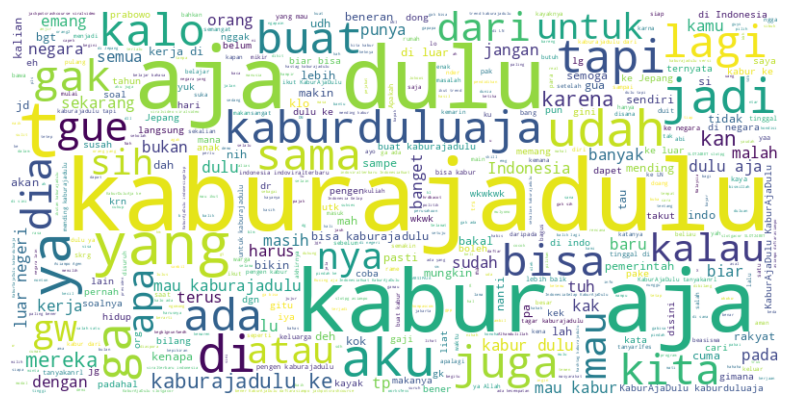

In [13]:
import pandas as pd
import numpy as np
from PIL import Image
from wordcloud import WordCloud, STOPWORDS, ImageColorGenerator
import matplotlib.pyplot as plt

# Memperbaiki kolom 'full text' (asumsi ini adalah kolom yang ingin Anda proses)
df['full_text'] = df['full_text'].fillna('')

# Membuat teks yang akan diolah menjadi wordcloud
text = ' '.join(df['full_text'].astype(str).tolist())

# Menyiapkan stopwords
stopwords = set(STOPWORDS)
stopwords.update({'https', 'co', 'RT', 'yg', 'dan', 'ini', 'itu', 'adalah', 'amp'}) # Contoh penambahan stopwords

# Membuat wordcloud
wc = WordCloud(stopwords=stopwords, background_color='white', max_words=500, width=800, height=400).generate(text)

# Menampilkan wordcloud
plt.figure(figsize=(10, 5))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.show()

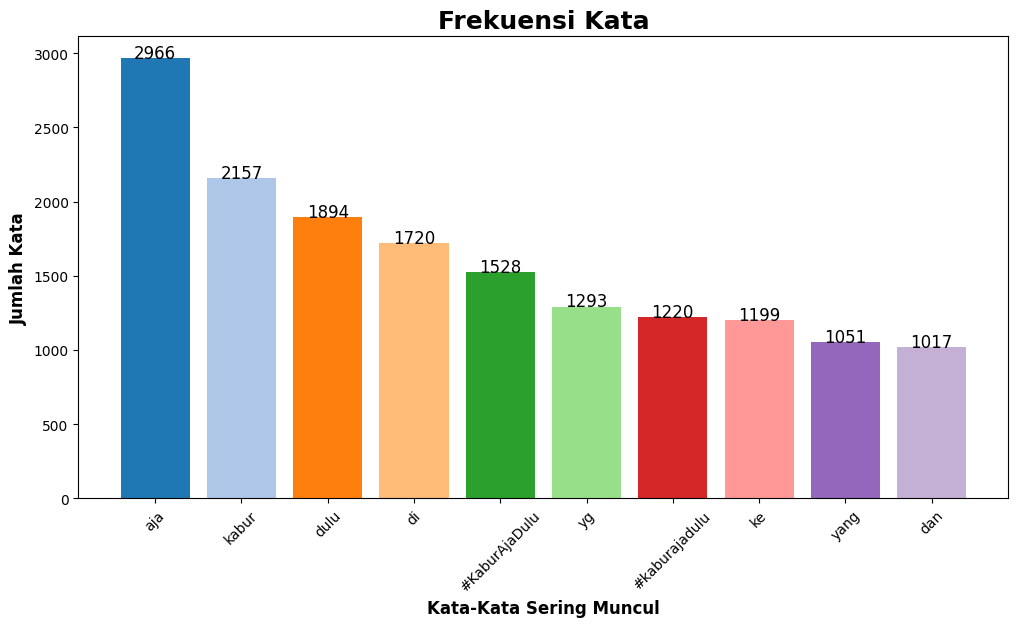

In [14]:
import matplotlib.pyplot as plt
from collections import Counter

# Mengambil teks dari kolom 'full_text'
text = ''.join(df['full_text'])

# Membagi teks menjadi token
tokens = text.split()

# Menghitung frekuensi kata
word_counts = Counter(tokens)

# Mendapatkan 10 kata yang paling sering muncul
top_words = word_counts.most_common(10)

# Membuat daftar kata dan frekuensinya
words, counts = zip(*top_words)

# Membuat warna untuk setiap kata
colors = plt.cm.tab20(range(len(words)))

# Membuat plot batang
plt.figure(figsize=(12, 6))
bars = plt.bar(words, counts, color=colors)

# Menambahkan label dan judul
plt.xlabel("Kata-Kata Sering Muncul", fontsize=12, fontweight="bold")
plt.ylabel("Jumlah Kata", fontsize=12, fontweight="bold")
plt.title("Frekuensi Kata", fontsize=18, fontweight="bold")

# Memutar label kata 45 derajat
plt.xticks(rotation=45)

# Menambahkan angka rata-rata di atas setiap batang
for bar, num in zip(bars, counts):
    plt.text(bar.get_x() + bar.get_width() / 2, num + 1, str(num), fontsize=12, color='black', ha="center")

# Menampilkan plot
plt.show()

### Filtering

In [15]:
print(df.columns)

Index(['full_text'], dtype='object')


In [16]:
df = df.drop(columns=[col for col in df.columns if col != 'full_text'])

In [17]:
# Fungsi untuk menghapus emoji
def remove_emoji(tweet):
    if tweet is not None and isinstance(tweet, str):
        emoji_pattern = re.compile("["
                           u"\U0001F600-\U0001F64F"  # emoticons
                           u"\U0001F300-\U0001F5FF"  # symbols & pictographs
                           u"\U0001F680-\U0001F6FF"  # transport & map symbols
                           u"\U0001F700-\U0001F77F"  # alchemical symbols
                           u"\U0001F780-\U0001F7FF"  # Geometric Shapes Extended
                           u"\U0001F800-\U0001F8FF"  # Supplemental Arrows-C
                           u"\U0001F900-\U0001F9FF"  # Supplemental Symbols and Pictographs
                           u"\U0001FA00-\U0001FA6F"  # Chess Symbols
                           u"\U0001FA70-\U0001FAFF"  # Symbols and Pictographs Extended-A
                           u"\U0001F004-\U0001F0CF"  # Additional emoticons
                           u"\U0001F1E0-\U0001F1FF"  # flags (iOS)
                           "]+", flags=re.UNICODE)
        return emoji_pattern.sub(r'', tweet)
    else:
        return tweet

# Fungsi untuk menghapus simbol
def remove_symbols(tweet):
    if tweet is not None and isinstance(tweet, str):
        tweet = re.sub(r'[^\w\s]', '', tweet) # Menghapus semua simbol
        return tweet

# Fungsi untuk menghapus angka
def remove_numbers(tweet):
    if tweet is not None and isinstance(tweet, str):
        tweet = re.sub(r'\d+', '', tweet) # Menghapus semua angka
        return tweet

def remove_username(text):
    import re
    return re.sub(r'@[\S]+', '', text)

In [18]:
df['cleaning'] = df['full_text'].apply(lambda x: remove_username(x))
df['cleaning'] = df['cleaning'].apply(lambda x: remove_emoji(x))
df['cleaning'] = df['cleaning'].apply(lambda x: remove_symbols(x))
df['cleaning'] = df['cleaning'].apply(lambda x: remove_numbers(x))

df.head()

,full_text,cleaning
0,@kamto_adi Ayo om kami yakin kapasitas inteleg...,Ayo om kami yakin kapasitas intelegensi sampe...
1,@narkosun Liat berita nya sih dimintai keteran...,Liat berita nya sih dimintai keterangan berar...
2,@masitanut @SweetPi96985735 @tanyakanrl Yailah...,Yailah konten lu masih bahas paslon²an dija...
3,udahlah dadah semuanya mimpi kaburajadulu pupus,udahlah dadah semuanya mimpi kaburajadulu pupus
4,@stevy_mende @G0LIATH87 @Puspen_TNI palingan n...,palingan nanti ikuti yang lain KaburAjaDulu...


In [19]:
print(df.columns)

Index(['full_text', 'cleaning'], dtype='object')


## Case Folding

In [20]:
def case_folding(text):
    if isinstance(text, str):
        lowercase_text = text.lower()
        return lowercase_text
    else:
        return text

df['case_folding'] = df['cleaning'].apply(case_folding)
df.head().T

,0,1,2,3,4
full_text,@kamto_adi Ayo om kami yakin kapasitas inteleg...,@narkosun Liat berita nya sih dimintai keteran...,@masitanut @SweetPi96985735 @tanyakanrl Yailah...,udahlah dadah semuanya mimpi kaburajadulu pupus,@stevy_mende @G0LIATH87 @Puspen_TNI palingan n...
cleaning,Ayo om kami yakin kapasitas intelegensi sampe...,Liat berita nya sih dimintai keterangan berar...,Yailah konten lu masih bahas paslon²an dija...,udahlah dadah semuanya mimpi kaburajadulu pupus,palingan nanti ikuti yang lain KaburAjaDulu...
case_folding,ayo om kami yakin kapasitas intelegensi sampe...,liat berita nya sih dimintai keterangan berar...,yailah konten lu masih bahas paslon²an dija...,udahlah dadah semuanya mimpi kaburajadulu pupus,palingan nanti ikuti yang lain kaburajadulu...


## Normalisasi (Mengubah kata tidak baku menjadi baku)

In [21]:
def replace_taboo_words(text, kamus_tidak_baku):
    if isinstance(text, str):
        words = text.split()
        replaced_words = []
        kalimat_baku = []
        kata_diganti = []
        kata_tidak_baku_hash = []

        for word in words:
            if word in kamus_tidak_baku:
                baku_word = kamus_tidak_baku[word]
                if isinstance(baku_word, str) and all(char.isalpha() or char.isspace() for char in baku_word):
                    replaced_words.append(baku_word)
                    kalimat_baku.append(baku_word)
                    kata_diganti.append(word)
                    kata_tidak_baku_hash.append(hash(word))
                else:
                    replaced_words.append(word)
            else:
                replaced_words.append(word)
        replaced_text = ' '.join(replaced_words)
    else:
        replaced_text = ''
        kalimat_baku = []
        kata_diganti = []
        kata_tidak_baku_hash = []

    return replaced_text, kalimat_baku, kata_diganti, kata_tidak_baku_hash

In [22]:
# Baca dataset
data = pd.DataFrame(df[['full_text', 'cleaning', 'case_folding']])
data.head().T

,0,1,2,3,4
full_text,@kamto_adi Ayo om kami yakin kapasitas inteleg...,@narkosun Liat berita nya sih dimintai keteran...,@masitanut @SweetPi96985735 @tanyakanrl Yailah...,udahlah dadah semuanya mimpi kaburajadulu pupus,@stevy_mende @G0LIATH87 @Puspen_TNI palingan n...
cleaning,Ayo om kami yakin kapasitas intelegensi sampe...,Liat berita nya sih dimintai keterangan berar...,Yailah konten lu masih bahas paslon²an dija...,udahlah dadah semuanya mimpi kaburajadulu pupus,palingan nanti ikuti yang lain KaburAjaDulu...
case_folding,ayo om kami yakin kapasitas intelegensi sampe...,liat berita nya sih dimintai keterangan berar...,yailah konten lu masih bahas paslon²an dija...,udahlah dadah semuanya mimpi kaburajadulu pupus,palingan nanti ikuti yang lain kaburajadulu...


In [23]:
kamus_data = pd.read_csv('https://raw.githubusercontent.com/go0se05/PI/main/kamuskatabaku.csv')
kamus_tidak_baku = dict(zip(kamus_data['tidak_baku'], kamus_data['kata_baku']))
kamus_data

,tidak_baku,kata_baku
0,woww,wow
1,aminn,amin
2,met,selamat
3,netaas,menetas
4,keberpa,keberapa
...,...,...
15186,bang,abang
15187,kaka,kakak
15188,militia,militer
15189,bu,ibu


In [24]:
# Terapkan fungsi penggantian kata tidak baku
data['hasil_normalisasi'], data['Kata_Baku'], data['Kata_Tidak_Baku'], data['Kata_Tidak_Baku_Hash'] = zip(*data['case_folding'].apply(lambda x: replace_taboo_words(x, kamus_tidak_baku)))
# data.head(100)

df = pd.DataFrame(data[['full_text', 'cleaning', 'case_folding', 'hasil_normalisasi']])

In [25]:
df.head().T

,0,1,2,3,4
full_text,@kamto_adi Ayo om kami yakin kapasitas inteleg...,@narkosun Liat berita nya sih dimintai keteran...,@masitanut @SweetPi96985735 @tanyakanrl Yailah...,udahlah dadah semuanya mimpi kaburajadulu pupus,@stevy_mende @G0LIATH87 @Puspen_TNI palingan n...
cleaning,Ayo om kami yakin kapasitas intelegensi sampe...,Liat berita nya sih dimintai keterangan berar...,Yailah konten lu masih bahas paslon²an dija...,udahlah dadah semuanya mimpi kaburajadulu pupus,palingan nanti ikuti yang lain KaburAjaDulu...
case_folding,ayo om kami yakin kapasitas intelegensi sampe...,liat berita nya sih dimintai keterangan berar...,yailah konten lu masih bahas paslon²an dija...,udahlah dadah semuanya mimpi kaburajadulu pupus,palingan nanti ikuti yang lain kaburajadulu...
hasil_normalisasi,ayo om kami yakin kapasitas intelegensi sampea...,lihat berita ya sih dimintai keterangan berart...,yailah konten kamu masih bahas paslon²an dijam...,sudahlah dadah semuanya mimpi kaburajadulu pupus,palingan nanti ikuti yang lain kaburajadulu ka...


### Tokenizer

In [26]:
def tokenize(text):
    tokens = text.split()
    return tokens

df['tokenize'] = df['hasil_normalisasi'].apply(tokenize)

In [27]:
df.head().T

,0,1,2,3,4
full_text,@kamto_adi Ayo om kami yakin kapasitas inteleg...,@narkosun Liat berita nya sih dimintai keteran...,@masitanut @SweetPi96985735 @tanyakanrl Yailah...,udahlah dadah semuanya mimpi kaburajadulu pupus,@stevy_mende @G0LIATH87 @Puspen_TNI palingan n...
cleaning,Ayo om kami yakin kapasitas intelegensi sampe...,Liat berita nya sih dimintai keterangan berar...,Yailah konten lu masih bahas paslon²an dija...,udahlah dadah semuanya mimpi kaburajadulu pupus,palingan nanti ikuti yang lain KaburAjaDulu...
case_folding,ayo om kami yakin kapasitas intelegensi sampe...,liat berita nya sih dimintai keterangan berar...,yailah konten lu masih bahas paslon²an dija...,udahlah dadah semuanya mimpi kaburajadulu pupus,palingan nanti ikuti yang lain kaburajadulu...
hasil_normalisasi,ayo om kami yakin kapasitas intelegensi sampea...,lihat berita ya sih dimintai keterangan berart...,yailah konten kamu masih bahas paslon²an dijam...,sudahlah dadah semuanya mimpi kaburajadulu pupus,palingan nanti ikuti yang lain kaburajadulu ka...
tokenize,"[ayo, om, kami, yakin, kapasitas, intelegensi,...","[lihat, berita, ya, sih, dimintai, keterangan,...","[yailah, konten, kamu, masih, bahas, paslon²an...","[sudahlah, dadah, semuanya, mimpi, kaburajadul...","[palingan, nanti, ikuti, yang, lain, kaburajad..."


### stopwords

In [28]:
from nltk.corpus import stopwords
nltk.download('stopwords')
stop_words = stopwords.words('indonesian')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [29]:
def remove_stopwords(text):
    return [word for word in text if word not in stop_words]
df['stopwords removal'] = df['tokenize'].apply(lambda x: remove_stopwords(x))

In [30]:
df.head().T

,0,1,2,3,4
full_text,@kamto_adi Ayo om kami yakin kapasitas inteleg...,@narkosun Liat berita nya sih dimintai keteran...,@masitanut @SweetPi96985735 @tanyakanrl Yailah...,udahlah dadah semuanya mimpi kaburajadulu pupus,@stevy_mende @G0LIATH87 @Puspen_TNI palingan n...
cleaning,Ayo om kami yakin kapasitas intelegensi sampe...,Liat berita nya sih dimintai keterangan berar...,Yailah konten lu masih bahas paslon²an dija...,udahlah dadah semuanya mimpi kaburajadulu pupus,palingan nanti ikuti yang lain KaburAjaDulu...
case_folding,ayo om kami yakin kapasitas intelegensi sampe...,liat berita nya sih dimintai keterangan berar...,yailah konten lu masih bahas paslon²an dija...,udahlah dadah semuanya mimpi kaburajadulu pupus,palingan nanti ikuti yang lain kaburajadulu...
hasil_normalisasi,ayo om kami yakin kapasitas intelegensi sampea...,lihat berita ya sih dimintai keterangan berart...,yailah konten kamu masih bahas paslon²an dijam...,sudahlah dadah semuanya mimpi kaburajadulu pupus,palingan nanti ikuti yang lain kaburajadulu ka...
tokenize,"[ayo, om, kami, yakin, kapasitas, intelegensi,...","[lihat, berita, ya, sih, dimintai, keterangan,...","[yailah, konten, kamu, masih, bahas, paslon²an...","[sudahlah, dadah, semuanya, mimpi, kaburajadul...","[palingan, nanti, ikuti, yang, lain, kaburajad..."
stopwords removal,"[ayo, om, kapasitas, intelegensi, sampean, dok...","[lihat, berita, ya, sih, keterangan, saksi, do...","[yailah, konten, bahas, paslon²an, dijaman, mo...","[dadah, mimpi, kaburajadulu, pupus]","[palingan, ikuti, kaburajadulu, kayak, ferry, ..."


In [31]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8593 entries, 0 to 12766
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   full_text          8593 non-null   object
 1   cleaning           8593 non-null   object
 2   case_folding       8593 non-null   object
 3   hasil_normalisasi  8593 non-null   object
 4   tokenize           8593 non-null   object
 5   stopwords removal  8593 non-null   object
dtypes: object(6)
memory usage: 469.9+ KB


In [32]:
data = df.dropna()
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8593 entries, 0 to 12766
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   full_text          8593 non-null   object
 1   cleaning           8593 non-null   object
 2   case_folding       8593 non-null   object
 3   hasil_normalisasi  8593 non-null   object
 4   tokenize           8593 non-null   object
 5   stopwords removal  8593 non-null   object
dtypes: object(6)
memory usage: 469.9+ KB


In [33]:
!pip install deep-translator

### Steamming

In [34]:
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from tqdm import tqdm
import pandas as pd
import concurrent.futures
import json
import os
from google.colab import drive
import numpy as np

In [35]:
# Mount Google Drive for persistent cache
drive.mount('/content/drive')
CACHE_PATH = "/content/drive/MyDrive/stem_cache.json"

# Load or initialize cache
if os.path.exists(CACHE_PATH):
    with open(CACHE_PATH) as f:
        stem_cache = json.load(f)
else:
    stem_cache = {}

factory = StemmerFactory()

# Collect unique words
print("📥 Scanning documents...")
all_words = set()
for word_list in tqdm(df['stopwords removal'], desc="Scanning documents"):
    all_words.update(word_list)
print(f"✅ Found {len(all_words):,} unique words")

# Identify new words
unseen_words = [w for w in all_words if w not in stem_cache]
print(f"🔍 {len(unseen_words):,} words need stemming")

# Create stemmer instances PER WORKER
def create_stemmer():
    return factory.create_stemmer()

# Parallel processing optimized for Colab
def process_unseen_words(words, workers=2):
    chunk_size = min(500, max(50, len(words) // (workers * 4)))
    chunks = [words[i:i+chunk_size] for i in range(0, len(words), chunk_size)]

    results = {}

    with concurrent.futures.ProcessPoolExecutor(max_workers=workers) as executor:
        future_to_chunk = {
            executor.submit(process_chunk, chunk): chunk
            for chunk in chunks
        }

        for future in tqdm(concurrent.futures.as_completed(future_to_chunk),
                          total=len(chunks),
                          desc="⚡ Stemming"):
            chunk_result = future.result()
            results.update(chunk_result)

    return results

def process_chunk(words):
    stemmer = create_stemmer()
    return {word: stemmer.stem(word) for word in words}

if unseen_words:
    new_stems = process_unseen_words(unseen_words)
    stem_cache.update(new_stems)

    with open(CACHE_PATH, 'w') as f:
        json.dump(stem_cache, f)

# SIMPLER AND MORE RELIABLE APPLICATION
def cached_stem(word):
    return stem_cache.get(word, word)

tqdm.pandas(desc="📤 Applying stems to documents")
df['fixed_text'] = df['stopwords removal'].progress_apply(
    lambda words: ' '.join(cached_stem(word) for word in words)
)

print("\n✅ Processing complete!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
📥 Scanning documents...


Scanning documents: 100%|██████████| 8593/8593 [00:00<00:00, 567343.87it/s]


✅ Found 17,138 unique words
🔍 0 words need stemming


📤 Applying stems to documents: 100%|██████████| 8593/8593 [00:00<00:00, 211313.64it/s]


✅ Processing complete!


In [36]:
df.head().T

,0,1,2,3,4
full_text,@kamto_adi Ayo om kami yakin kapasitas inteleg...,@narkosun Liat berita nya sih dimintai keteran...,@masitanut @SweetPi96985735 @tanyakanrl Yailah...,udahlah dadah semuanya mimpi kaburajadulu pupus,@stevy_mende @G0LIATH87 @Puspen_TNI palingan n...
cleaning,Ayo om kami yakin kapasitas intelegensi sampe...,Liat berita nya sih dimintai keterangan berar...,Yailah konten lu masih bahas paslon²an dija...,udahlah dadah semuanya mimpi kaburajadulu pupus,palingan nanti ikuti yang lain KaburAjaDulu...
case_folding,ayo om kami yakin kapasitas intelegensi sampe...,liat berita nya sih dimintai keterangan berar...,yailah konten lu masih bahas paslon²an dija...,udahlah dadah semuanya mimpi kaburajadulu pupus,palingan nanti ikuti yang lain kaburajadulu...
hasil_normalisasi,ayo om kami yakin kapasitas intelegensi sampea...,lihat berita ya sih dimintai keterangan berart...,yailah konten kamu masih bahas paslon²an dijam...,sudahlah dadah semuanya mimpi kaburajadulu pupus,palingan nanti ikuti yang lain kaburajadulu ka...
tokenize,"[ayo, om, kami, yakin, kapasitas, intelegensi,...","[lihat, berita, ya, sih, dimintai, keterangan,...","[yailah, konten, kamu, masih, bahas, paslon²an...","[sudahlah, dadah, semuanya, mimpi, kaburajadul...","[palingan, nanti, ikuti, yang, lain, kaburajad..."
stopwords removal,"[ayo, om, kapasitas, intelegensi, sampean, dok...","[lihat, berita, ya, sih, keterangan, saksi, do...","[yailah, konten, bahas, paslon²an, dijaman, mo...","[dadah, mimpi, kaburajadulu, pupus]","[palingan, ikuti, kaburajadulu, kayak, ferry, ..."
fixed_text,ayo om kapasitas intelegensi sampean doktrin m...,lihat berita ya sih terang saksi doang kaburaj...,yailah konten bahas paslon an jam modern move ...,dadah mimpi kaburajadulu pupus,paling ikut kaburajadulu kayak ferry dkk


In [37]:
data = df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8593 entries, 0 to 12766
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   full_text          8593 non-null   object
 1   cleaning           8593 non-null   object
 2   case_folding       8593 non-null   object
 3   hasil_normalisasi  8593 non-null   object
 4   tokenize           8593 non-null   object
 5   stopwords removal  8593 non-null   object
 6   fixed_text         8593 non-null   object
dtypes: object(7)
memory usage: 537.1+ KB


### WordCloud

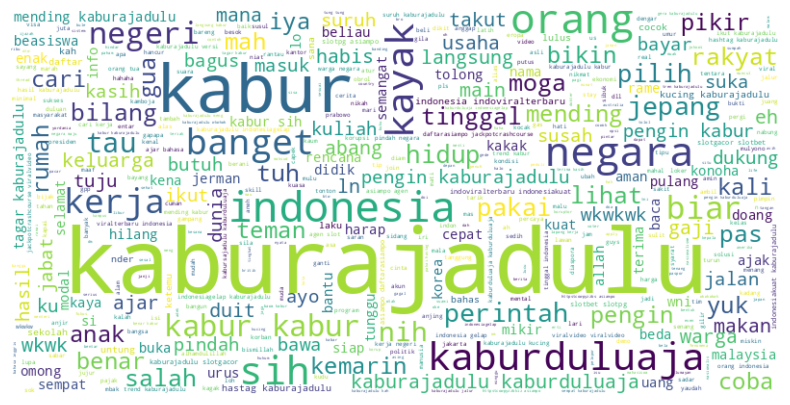

In [38]:
import pandas as pd
import numpy as np
from wordcloud import WordCloud, STOPWORDS
import matplotlib.pyplot as plt

# Gabungkan teks dari kolom 'stemming_data' dari DataFrame df
text = ' '.join(df['fixed_text'].astype(str).tolist())

# Siapkan stopwords tambahan
stopwords = set(STOPWORDS)
stopwords.update(['https', 'co', 'RT', 'amp', 'lu', 'deh', 'fyp', 'ya', 'gue', 'kak', 'tan','utk','ala'])

# Buat dan tampilkan WordCloud
wc = WordCloud(stopwords=stopwords, background_color="white", max_words=500, width=800, height=400).generate(text)

plt.figure(figsize=(10, 5))
plt.imshow(wc, interpolation='bilinear')
plt.axis("off")
plt.show()

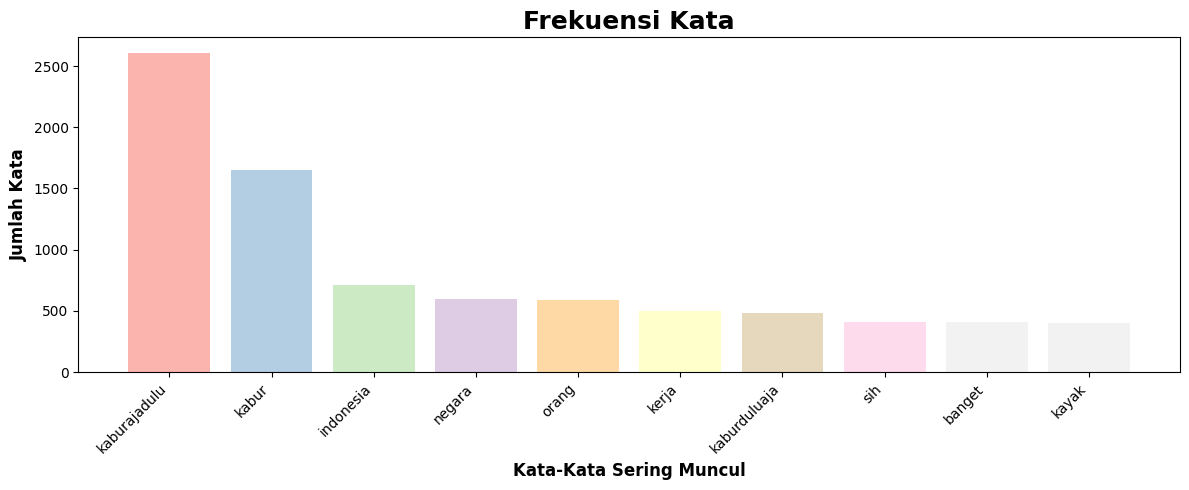

In [39]:
import matplotlib.pyplot as plt
from collections import Counter
from wordcloud import STOPWORDS

text = ".".join(df['fixed_text'])
stopwords = set(STOPWORDS)
stopwords.update(['https', 'co', 'RT', '...', 'amp', 'lu', 'deh', 'fyp', 'ya', 'gue', 'kak', 'tan', 'pemerintahkanggajiguru', 'ajar'])
tokens = [word for word in text.split() if word not in stopwords]
word_counts = Counter(tokens)

top_words = word_counts.most_common(10)
word, count = zip(*top_words)

# Menggunakan palet warna lebih soft
colors = plt.cm.Pastel1(range(len(word)))

# Membuat plot
plt.figure(figsize=(12, 5))
bars = plt.bar(word, count, color=colors)
plt.xlabel("Kata-Kata Sering Muncul", fontsize=12, fontweight='bold')
plt.ylabel("Jumlah Kata", fontsize=12, fontweight='bold')
plt.title("Frekuensi Kata", fontsize=18, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [40]:
# Simpan DataFrame ke file Excel
df.to_csv('data_preprocessing.csv', index=False)

# Pelabelan Data dengan Lexicon Based

In [41]:
# Membaca data dari file Excel
data = pd.read_csv("data_preprocessing.csv")

data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8593 entries, 0 to 8592
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   full_text          8593 non-null   object
 1   cleaning           8593 non-null   object
 2   case_folding       8593 non-null   object
 3   hasil_normalisasi  8593 non-null   object
 4   tokenize           8593 non-null   object
 5   stopwords removal  8593 non-null   object
 6   fixed_text         8592 non-null   object
dtypes: object(7)
memory usage: 470.1+ KB


In [42]:
kolom_selain_list = [col for col in df.columns if not isinstance(df[col].iloc[0], list) if len(df) > 0]

if kolom_selain_list:
    print(f"Jumlah data duplikat (tanpa kolom list): {df[kolom_selain_list].duplicated().sum()}")
    print(f"Jumlah missing values (pada kolom selain list): {df[kolom_selain_list].isnull().sum().sum()}")
else:
    print("Tidak ada kolom selain list untuk diperiksa duplikasi.")

data = data.dropna()
data.info()

Jumlah data duplikat (tanpa kolom list): 0
Jumlah missing values (pada kolom selain list): 0
<class 'pandas.core.frame.DataFrame'>
Index: 8592 entries, 0 to 8592
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   full_text          8592 non-null   object
 1   cleaning           8592 non-null   object
 2   case_folding       8592 non-null   object
 3   hasil_normalisasi  8592 non-null   object
 4   tokenize           8592 non-null   object
 5   stopwords removal  8592 non-null   object
 6   fixed_text         8592 non-null   object
dtypes: object(7)
memory usage: 537.0+ KB


In [43]:
import pandas as pd
import requests
from io import StringIO

# URL yang valid untuk leksikon
positive_url = "https://raw.githubusercontent.com/fajri91/InSet/master/positive.tsv"
negative_url = "https://raw.githubusercontent.com/fajri91/InSet/master/negative.tsv"
positive_csv = "https://raw.githubusercontent.com/angelmetanosaa/dataset/main/lexicon_positive.csv"
negative_csv = "https://raw.githubusercontent.com/angelmetanosaa/dataset/main/lexicon_negative.csv"

# Fungsi untuk memuat leksikon dengan error handling
def load_lexicon(source, is_csv=False):
    try:
        # Download konten
        response = requests.get(source)
        response.raise_for_status()  # Akan error jika status code bukan 200

        if is_csv:
            # Baca CSV langsung dari string
            df = pd.read_csv(StringIO(response.text))

            # Cari kolom yang sesuai
            word_col = None
            for col in df.columns:
                if 'word' in col.lower() or 'kata' in col.lower() or 'term' in col.lower():
                    word_col = col
                    break

            # Jika tidak ditemukan kolom khusus, gunakan kolom pertama
            word_col = word_col if word_col else df.columns[0]

            # Konversi ke lowercase dan buat set
            return set(df[word_col].astype(str).str.lower().dropna().unique())
        else:
            # Untuk format TSV/TXT
            lines = response.text.split('\n')
            words = [line.split('\t')[0].strip().lower() for line in lines if line.strip()]
            return set(words)
    except Exception as e:
        print(f"⚠️ Error loading {source}: {str(e)}")
        return set()

# Muat semua leksikon positif
positive_lexicon = set()
positive_lexicon.update(load_lexicon(positive_url))
positive_lexicon.update(load_lexicon(positive_csv, is_csv=True))

# Muat semua leksikon negatif
negative_lexicon = set()
negative_lexicon.update(load_lexicon(negative_url))
negative_lexicon.update(load_lexicon(negative_csv, is_csv=True))

# Tambahkan custom lexicon
custom_positive = {"untung", "banget", "ya", "mantap", "oke", "bagus", "baik", "senang", "puas"}
custom_negative = {"nganggur", "wrong", "militer", "buruk", "gagal", "jelek", "susah", "sulit", "kabur"}

positive_lexicon.update(custom_positive)
negative_lexicon.update(custom_negative)

# Hapus kata yang muncul di kedua leksikon (konflik)
conflict_words = positive_lexicon & negative_lexicon
positive_lexicon -= conflict_words
negative_lexicon -= conflict_words

# Print statistik
print(f"\n📊 Lexicon Statistics:")
print(f"Positive words: {len(positive_lexicon):,}")
print(f"Negative words: {len(negative_lexicon):,}")
print(f"Conflict words removed: {len(conflict_words):,}")
print(f"Sample positive: {list(positive_lexicon)[:5]}")
print(f"Sample negative: {list(negative_lexicon)[:5]}")

# Optimasi: buat dictionary untuk pencarian cepat
word_scores = {}
for word in positive_lexicon:
    word_scores[word] = 1
for word in negative_lexicon:
    word_scores[word] = -1

# Fungsi analisis sentimen
def determine_sentiment(text):
    if not isinstance(text, str) or not text.strip():
        return 0, "Netral"

    words = text.split()
    score = 0
    found_positive = 0
    found_negative = 0

    for word in words:
        if word in word_scores:
            sentiment = word_scores[word]
            score += sentiment
            if sentiment > 0:
                found_positive += 1
            else:
                found_negative += 1

    # Aturan tambahan untuk netral
    if score == 0:
        if found_negative > 0:
            return -1, "Negatif"
        return 0, "Netral"

    return score, "Positif" if score > 0 else "Negatif"

# Terapkan ke dataframe
print("\n⏳ Calculating sentiment scores...")
data[['Score', 'label']] = data['fixed_text'].apply(
    lambda x: pd.Series(determine_sentiment(x))
)

# Tampilkan hasil
print("\n✅ Sentiment analysis completed!")
data[['fixed_text', 'Score', 'label']].head(10).T


📊 Lexicon Statistics:
Positive words: 2,465
Negative words: 5,467
Conflict words removed: 1,143
Sample positive: ['mengucil', 'berkekuatan', 'berkecukupan', 'ya', 'kelelawar']
Sample negative: ['laif', 'lemau', 'kalau', 'menghancurluluhkan', 'ikut-ikutan']

⏳ Calculating sentiment scores...

✅ Sentiment analysis completed!


,0,1,2,3,4,5,6,7,8,9
fixed_text,ayo om kapasitas intelegensi sampean doktrin m...,lihat berita ya sih terang saksi doang kaburaj...,yailah konten bahas paslon an jam modern move ...,dadah mimpi kaburajadulu pupus,paling ikut kaburajadulu kayak ferry dkk,anjg gue kapai malu gue gass cok lumayan prepa...,please deh konyol jepang kasihan anak anak mud...,kucing kaburajadulu,iri tementemen kaburajadulu,mah benar kaburajadulu
Score,-1,2,1,-1,-2,1,-7,0,-1,0
label,Negatif,Positif,Positif,Negatif,Negatif,Positif,Negatif,Netral,Negatif,Netral


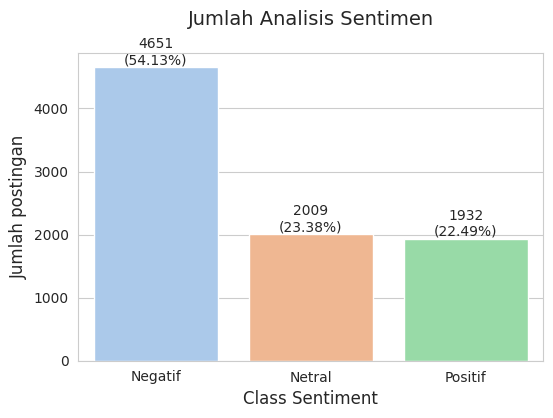

In [44]:
sentiment_count = data['label'].value_counts()
sns.set_style('whitegrid')
fig, ax = plt.subplots(figsize=(6, 4))
ax = sns.barplot(x=sentiment_count.index, y=sentiment_count.values, hue=sentiment_count.index, legend=False, palette='pastel')
plt.title('Jumlah Analisis Sentimen', fontsize=14, pad=20)
plt.xlabel('Class Sentiment', fontsize=12)
plt.ylabel('Jumlah postingan', fontsize=12)

total = len(data['label'])
for i, count in enumerate(sentiment_count.values):
    percentage = f'{100 * count / total:.2f}%'
    ax.text(i, count + 0.10, f'{count}\n({percentage})', ha='center', va='bottom')

plt.show()

In [45]:
# Simpan DataFrame ke file Excel
data.to_csv('data_labeling.csv', index=False)

In [46]:
# Membaca data dari file Excel
data = pd.read_csv("data_labeling.csv")

data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8592 entries, 0 to 8591
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   full_text          8592 non-null   object
 1   cleaning           8592 non-null   object
 2   case_folding       8592 non-null   object
 3   hasil_normalisasi  8592 non-null   object
 4   tokenize           8592 non-null   object
 5   stopwords removal  8592 non-null   object
 6   fixed_text         8592 non-null   object
 7   Score              8592 non-null   int64 
 8   label              8592 non-null   object
dtypes: int64(1), object(8)
memory usage: 604.3+ KB


In [47]:
from sklearn.preprocessing import OrdinalEncoder

label_order = [['Negatif','Positif','Netral']]

# Initialize the OrdinalEncoder with the specified order for the 'status' column
ordinal_encoder = OrdinalEncoder(categories=label_order)

# Fit and transform the 'status' column
data['label_encoded'] = ordinal_encoder.fit_transform(data[['label']])

In [48]:
data.head()

,full_text,cleaning,case_folding,hasil_normalisasi,tokenize,stopwords removal,fixed_text,Score,label,label_encoded
0,@kamto_adi Ayo om kami yakin kapasitas inteleg...,Ayo om kami yakin kapasitas intelegensi sampe...,ayo om kami yakin kapasitas intelegensi sampe...,ayo om kami yakin kapasitas intelegensi sampea...,"['ayo', 'om', 'kami', 'yakin', 'kapasitas', 'i...","['ayo', 'om', 'kapasitas', 'intelegensi', 'sam...",ayo om kapasitas intelegensi sampean doktrin m...,-1,Negatif,0.0
1,@narkosun Liat berita nya sih dimintai keteran...,Liat berita nya sih dimintai keterangan berar...,liat berita nya sih dimintai keterangan berar...,lihat berita ya sih dimintai keterangan berart...,"['lihat', 'berita', 'ya', 'sih', 'dimintai', '...","['lihat', 'berita', 'ya', 'sih', 'keterangan',...",lihat berita ya sih terang saksi doang kaburaj...,2,Positif,1.0
2,@masitanut @SweetPi96985735 @tanyakanrl Yailah...,Yailah konten lu masih bahas paslon²an dija...,yailah konten lu masih bahas paslon²an dija...,yailah konten kamu masih bahas paslon²an dijam...,"['yailah', 'konten', 'kamu', 'masih', 'bahas',...","['yailah', 'konten', 'bahas', 'paslon²an', 'di...",yailah konten bahas paslon an jam modern move ...,1,Positif,1.0
3,udahlah dadah semuanya mimpi kaburajadulu pupus,udahlah dadah semuanya mimpi kaburajadulu pupus,udahlah dadah semuanya mimpi kaburajadulu pupus,sudahlah dadah semuanya mimpi kaburajadulu pupus,"['sudahlah', 'dadah', 'semuanya', 'mimpi', 'ka...","['dadah', 'mimpi', 'kaburajadulu', 'pupus']",dadah mimpi kaburajadulu pupus,-1,Negatif,0.0
4,@stevy_mende @G0LIATH87 @Puspen_TNI palingan n...,palingan nanti ikuti yang lain KaburAjaDulu...,palingan nanti ikuti yang lain kaburajadulu...,palingan nanti ikuti yang lain kaburajadulu ka...,"['palingan', 'nanti', 'ikuti', 'yang', 'lain',...","['palingan', 'ikuti', 'kaburajadulu', 'kayak',...",paling ikut kaburajadulu kayak ferry dkk,-2,Negatif,0.0


In [49]:
kolom_selain_list = [col for col in df.columns if not isinstance(df[col].iloc[0], list) if len(df) > 0]

if kolom_selain_list:
    print(f"Jumlah data duplikat (tanpa kolom list): {df[kolom_selain_list].duplicated().sum()}")
    print(f"Jumlah missing values (pada kolom selain list): {df[kolom_selain_list].isnull().sum().sum()}")
else:
    print("Tidak ada kolom selain list untuk diperiksa duplikasi.")

data = data.dropna()
data.info()

Jumlah data duplikat (tanpa kolom list): 0
Jumlah missing values (pada kolom selain list): 0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8592 entries, 0 to 8591
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   full_text          8592 non-null   object 
 1   cleaning           8592 non-null   object 
 2   case_folding       8592 non-null   object 
 3   hasil_normalisasi  8592 non-null   object 
 4   tokenize           8592 non-null   object 
 5   stopwords removal  8592 non-null   object 
 6   fixed_text         8592 non-null   object 
 7   Score              8592 non-null   int64  
 8   label              8592 non-null   object 
 9   label_encoded      8592 non-null   float64
dtypes: float64(1), int64(1), object(8)
memory usage: 671.4+ KB


## Wordcloud Positive, Negative & Neutral

In [50]:
# Filter data untuk label positif dan gabungkan teks
positive_data = data[data['label'] == 'Positif']
text_positive = ' '.join(positive_data['fixed_text'].astype(str).tolist())
print(f"Jumlah kata dalam sentimen positif: {len(text_positive.split())}")

# Filter data untuk label negatif dan gabungkan teks
negative_data = data[data['label'] == 'Negatif']
text_negative = ' '.join(negative_data['fixed_text'].astype(str).tolist())
print(f"Jumlah kata dalam sentimen negatif: {len(text_negative.split())}")

# Filter data untuk label netral dan gabungkan teks
neutral_data = data[data['label'] == 'Netral']
text_neutral = ' '.join(neutral_data['fixed_text'].astype(str).tolist())
print(f"Jumlah kata dalam sentimen netral: {len(text_neutral.split())}")

Jumlah kata dalam sentimen positif: 22119
Jumlah kata dalam sentimen negatif: 47603
Jumlah kata dalam sentimen netral: 7249


In [51]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

def generate_wordcloud(text, title):
    """
    Menghasilkan dan menampilkan word cloud dari teks yang diberikan.

    Args:
        text (str): Teks yang akan dianalisis untuk membuat word cloud.
        title (str): Judul dari plot word cloud.
    """
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(title)
    plt.show()

#### Word cloud Positif

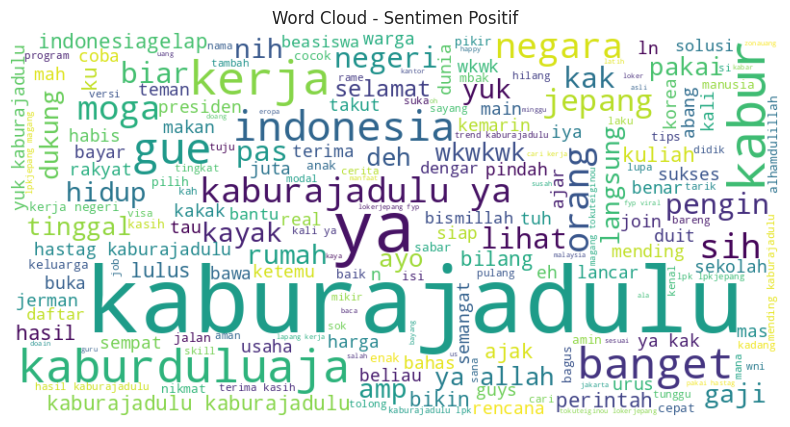

In [52]:
# Buat word cloud untuk sentimen positif
generate_wordcloud(text_positive, "Word Cloud - Sentimen Positif")

#### Word cloud Negatif

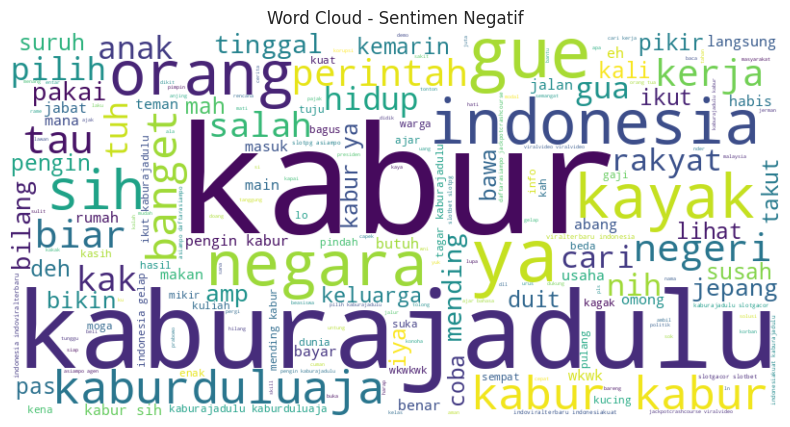

In [53]:
# Buat word cloud untuk sentimen negatif
generate_wordcloud(text_negative, "Word Cloud - Sentimen Negatif")

#### Word cloud Netral

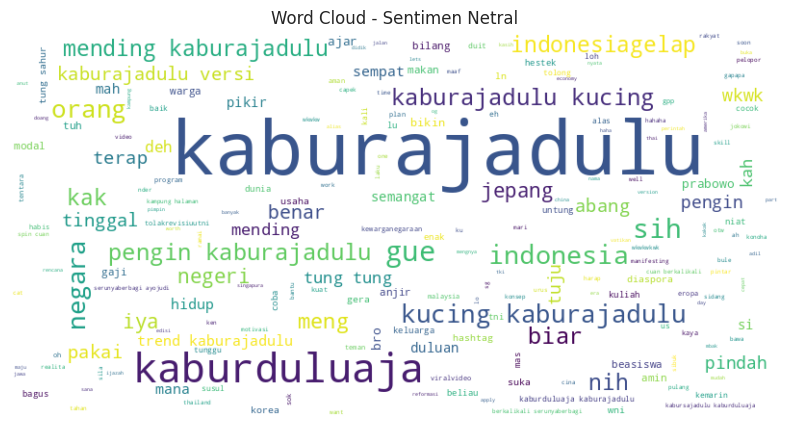

In [54]:
# Buat word cloud untuk sentimen netral
generate_wordcloud(text_neutral, "Word Cloud - Sentimen Netral")

In [55]:
# Membaca data dari file Excel
data = pd.read_csv("data_labeling.csv")

data.head()

,full_text,cleaning,case_folding,hasil_normalisasi,tokenize,stopwords removal,fixed_text,Score,label
0,@kamto_adi Ayo om kami yakin kapasitas inteleg...,Ayo om kami yakin kapasitas intelegensi sampe...,ayo om kami yakin kapasitas intelegensi sampe...,ayo om kami yakin kapasitas intelegensi sampea...,"['ayo', 'om', 'kami', 'yakin', 'kapasitas', 'i...","['ayo', 'om', 'kapasitas', 'intelegensi', 'sam...",ayo om kapasitas intelegensi sampean doktrin m...,-1,Negatif
1,@narkosun Liat berita nya sih dimintai keteran...,Liat berita nya sih dimintai keterangan berar...,liat berita nya sih dimintai keterangan berar...,lihat berita ya sih dimintai keterangan berart...,"['lihat', 'berita', 'ya', 'sih', 'dimintai', '...","['lihat', 'berita', 'ya', 'sih', 'keterangan',...",lihat berita ya sih terang saksi doang kaburaj...,2,Positif
2,@masitanut @SweetPi96985735 @tanyakanrl Yailah...,Yailah konten lu masih bahas paslon²an dija...,yailah konten lu masih bahas paslon²an dija...,yailah konten kamu masih bahas paslon²an dijam...,"['yailah', 'konten', 'kamu', 'masih', 'bahas',...","['yailah', 'konten', 'bahas', 'paslon²an', 'di...",yailah konten bahas paslon an jam modern move ...,1,Positif
3,udahlah dadah semuanya mimpi kaburajadulu pupus,udahlah dadah semuanya mimpi kaburajadulu pupus,udahlah dadah semuanya mimpi kaburajadulu pupus,sudahlah dadah semuanya mimpi kaburajadulu pupus,"['sudahlah', 'dadah', 'semuanya', 'mimpi', 'ka...","['dadah', 'mimpi', 'kaburajadulu', 'pupus']",dadah mimpi kaburajadulu pupus,-1,Negatif
4,@stevy_mende @G0LIATH87 @Puspen_TNI palingan n...,palingan nanti ikuti yang lain KaburAjaDulu...,palingan nanti ikuti yang lain kaburajadulu...,palingan nanti ikuti yang lain kaburajadulu ka...,"['palingan', 'nanti', 'ikuti', 'yang', 'lain',...","['palingan', 'ikuti', 'kaburajadulu', 'kayak',...",paling ikut kaburajadulu kayak ferry dkk,-2,Negatif


In [56]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8592 entries, 0 to 8591
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   full_text          8592 non-null   object
 1   cleaning           8592 non-null   object
 2   case_folding       8592 non-null   object
 3   hasil_normalisasi  8592 non-null   object
 4   tokenize           8592 non-null   object
 5   stopwords removal  8592 non-null   object
 6   fixed_text         8592 non-null   object
 7   Score              8592 non-null   int64 
 8   label              8592 non-null   object
dtypes: int64(1), object(8)
memory usage: 604.3+ KB


In [57]:
# Tentukan sentimen dan skor untuk setiap ulasan
data[['Score', 'label']] = data['fixed_text'].apply(lambda x: pd.Series(determine_sentiment(x)))

data.T

,0,1,2,3,4,5,6,7,8,9,...,8582,8583,8584,8585,8586,8587,8588,8589,8590,8591
full_text,@kamto_adi Ayo om kami yakin kapasitas inteleg...,@narkosun Liat berita nya sih dimintai keteran...,@masitanut @SweetPi96985735 @tanyakanrl Yailah...,udahlah dadah semuanya mimpi kaburajadulu pupus,@stevy_mende @G0LIATH87 @Puspen_TNI palingan n...,@bsvboomtrnt Anjg gw kalau jadi lu ngapain mal...,Please deh jangan melakukan hal kekonyolan di ...,@JIguJELlyyys kucingnya: #kaburajadulu,Iri sama temen-temen yang udah #kaburajadulu,@sunsainee Ini mah bnran harus #kaburajadulu,...,@Aldyscofield #kaburajadulu,@Adeoktavianii #KaburAjaDulu,Alhamdulillah So this is life after UTBEKAH fi...,Najis banget minggu gue masih ngurus kerjaan S...,@Keshilist #kaburajadulu,#kaburajadulu https://t.co/BgsLAtyrrh,@jokowi #kaburajadulu,@sungjun05z #kaburajadulu,@veoses #kaburajadulu ‍️‍️,Day 4 Stream Everyday Until I #KaburAjaDulu /...
cleaning,Ayo om kami yakin kapasitas intelegensi sampe...,Liat berita nya sih dimintai keterangan berar...,Yailah konten lu masih bahas paslon²an dija...,udahlah dadah semuanya mimpi kaburajadulu pupus,palingan nanti ikuti yang lain KaburAjaDulu...,Anjg gw kalau jadi lu ngapain malu gw gass aj...,Please deh jangan melakukan hal kekonyolan di ...,kucingnya kaburajadulu,Iri sama tementemen yang udah kaburajadulu,Ini mah bnran harus kaburajadulu,...,kaburajadulu,KaburAjaDulu,Alhamdulillah So this is life after UTBEKAH fi...,Najis banget minggu gue masih ngurus kerjaan S...,kaburajadulu,kaburajadulu httpstcoBgsLAtyrrh,kaburajadulu,kaburajadulu,kaburajadulu,Day Stream Everyday Until I KaburAjaDulu home
case_folding,ayo om kami yakin kapasitas intelegensi sampe...,liat berita nya sih dimintai keterangan berar...,yailah konten lu masih bahas paslon²an dija...,udahlah dadah semuanya mimpi kaburajadulu pupus,palingan nanti ikuti yang lain kaburajadulu...,anjg gw kalau jadi lu ngapain malu gw gass aj...,please deh jangan melakukan hal kekonyolan di ...,kucingnya kaburajadulu,iri sama tementemen yang udah kaburajadulu,ini mah bnran harus kaburajadulu,...,kaburajadulu,kaburajadulu,alhamdulillah so this is life after utbekah fi...,najis banget minggu gue masih ngurus kerjaan s...,kaburajadulu,kaburajadulu httpstcobgslatyrrh,kaburajadulu,kaburajadulu,kaburajadulu,day stream everyday until i kaburajadulu home
hasil_normalisasi,ayo om kami yakin kapasitas intelegensi sampea...,lihat berita ya sih dimintai keterangan berart...,yailah konten kamu masih bahas paslon²an dijam...,sudahlah dadah semuanya mimpi kaburajadulu pupus,palingan nanti ikuti yang lain kaburajadulu ka...,anjg gue kalau jadi kamu mengapai malu gue gas...,please deh jangan melakukan hal kekonyolan di ...,kucingnya kaburajadulu,iri sama tementemen yang sudah kaburajadulu,ini mah benaran harus kaburajadulu,...,kaburajadulu,kaburajadulu,alhamdulillah sok this is life after utbekah f...,najis banget minggu gue masih mengurus pekerja...,kaburajadulu,kaburajadulu httpstcobgslatyrrh,kaburajadulu,kaburajadulu,kaburajadulu,day stream everyday until i kaburajadulu home
tokenize,"['ayo', 'om', 'kami', 'yakin', 'kapasitas', 'i...","['lihat', 'berita', 'ya', 'sih', 'dimintai', '...","['yailah', 'konten', 'kamu', 'masih', 'bahas',...","['sudahlah', 'dadah', 'semuanya', 'mimpi', 'ka...","['palingan', 'nanti', 'ikuti', 'yang', 'lain',...","['anjg', 'gue', 'kalau', 'jadi', 'kamu', 'meng...","['please', 'deh', 'jangan', 'melakukan', 'hal'...","['kucingnya', 'kaburajadulu']","['iri', 'sama', 'tementemen', 'yang', 'sudah',...","['ini', 'mah', 'benaran', 'harus', 'kaburajadu...",...,['kaburajadulu'],['kaburajadulu'],"['alhamdulillah', 'sok', 'this', 'is', 'life',...","['najis', 'banget', 'minggu', 'gue', 'masih', ...",['kaburajadulu'],"['kaburajadulu', 'httpstcobgslatyrrh']",['kaburajadulu'],['kaburajadulu'],['kaburajadulu'],"['day', 'stream', 'everyday', 'until', 'i', 'k..."
stopwords removal,"['ayo', 'om', 'kapasitas', 'intelegensi', 'sam...","['lihat', 'berita', 'ya', 'sih', 'keterangan',...","['yailah

In [58]:
label_count = data['label'].value_counts()
print(label_count)

label
Negatif    4651
Netral     2009
Positif    1932
Name: count, dtype: int64


# Pemodelan

## Import Library

In [59]:
# Block 1: Import Library
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score, precision_score, recall_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from imblearn.pipeline import make_pipeline
from imblearn.over_sampling import SMOTE
from scipy.stats import loguniform, randint

## Data Preparation

In [60]:
# Block 2: Persiapan Data dan Label Encoding
print("🔧 Preparing data...")
X = data['fixed_text']  # Kolom fitur
y = data['label']       # Kolom target

print("🔢 Encoding labels...")
le = LabelEncoder()
y_encoded = le.fit_transform(y)

label_mapping = dict(zip(le.classes_, le.transform(le.classes_)))
print(f"Label mapping: {label_mapping}")

🔧 Preparing data...
🔢 Encoding labels...
Label mapping: {'Negatif': np.int64(0), 'Netral': np.int64(1), 'Positif': np.int64(2)}


In [61]:
# Block 3: TF-IDF Vectorization
print("🔧 Optimizing TF-IDF Vectorizer...")
vectorizer = TfidfVectorizer(
    ngram_range=(1, 2),
    max_features=10000,
    sublinear_tf=True
)
X_transformed = vectorizer.fit_transform(X)

🔧 Optimizing TF-IDF Vectorizer...


In [62]:
# Block 4: Split Data
print("✂️ Splitting data...")
X_train, X_test, y_train, y_test = train_test_split(
    X_transformed,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

print(f"Training shape: {X_train.shape}")
print(f"Testing shape: {X_test.shape}")

✂️ Splitting data...
Training shape: (6873, 10000)
Testing shape: (1719, 10000)


## Build Model

In [63]:
# Block 5: Inisialisasi Model dan Parameter Grid
print("🤖 Initializing models...")
classifiers = {
    "Logistic Regression": make_pipeline(
        SMOTE(random_state=42, sampling_strategy='auto'),
        LogisticRegression(max_iter=1000, n_jobs=-1, random_state=42)
    ),
    "Random Forest": make_pipeline(
        SMOTE(random_state=42, sampling_strategy='auto'),
        RandomForestClassifier(random_state=42, n_jobs=-1)
    ),
    "Naive Bayes": make_pipeline(
        SMOTE(random_state=42, sampling_strategy='auto'),
        MultinomialNB()
    )
}

# Parameter grids
param_grids = {
    "Logistic Regression": {
        'logisticregression__C': loguniform(1e-3, 100),
        'logisticregression__solver': ['liblinear', 'saga']
    },
    "Random Forest": {
        'randomforestclassifier__n_estimators': randint(100, 500),
        'randomforestclassifier__max_depth': [None, 10, 30, 50],
        'randomforestclassifier__min_samples_split': randint(2, 20)
    },
    "Naive Bayes": {
        'multinomialnb__alpha': [0.1, 0.5, 1.0, 1.5, 2.0]
    }
}

🤖 Initializing models...


## Train and evaluate

In [64]:
# Block 6: Fungsi untuk Melatih dan Mengevaluasi Model
def train_and_evaluate_model(name, pipeline, param_grid):
    print(f"\n{'='*50}")
    print(f"⚙️ Optimizing {name}...")
    print(f"{'='*50}")

    try:
        # Setup RandomizedSearchCV
        search = RandomizedSearchCV(
            pipeline,
            param_grid,
            n_iter=10 if name == "Random Forest" else 15,
            cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=42),
            scoring='f1_weighted',
            n_jobs=-1,
            random_state=42,
            verbose=1,
            error_score='raise'
        )

        # Training
        search.fit(X_train, y_train)
        best_model = search.best_estimator_

        # Prediction
        y_pred = best_model.predict(X_test)

        # Evaluation metrics
        accuracy = accuracy_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred, average='weighted')
        precision = precision_score(y_test, y_pred, average='weighted')
        recall = recall_score(y_test, y_pred, average='weighted')

        # Save results
        result = {
            'accuracy': accuracy,
            'f1': f1,
            'precision': precision,
            'recall': recall,
            'best_params': search.best_params_,
            'report': classification_report(y_test, y_pred, output_dict=True),
            'matrix': confusion_matrix(y_test, y_pred),
            'model': best_model
        }

        # Print results
        print(f"\n✅ {name} optimization complete!")
        print(f"Best Parameters: {search.best_params_}")
        print(f"Accuracy: {accuracy:.4f}")
        print(f"F1-Score: {f1:.4f}")
        print("Classification Report:")
        print(classification_report(y_test, y_pred, target_names=le.classes_))

        # Plot confusion matrix
        plt.figure(figsize=(8, 6))
        sns.heatmap(
            confusion_matrix(y_test, y_pred),
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=le.classes_,
            yticklabels=le.classes_
        )
        plt.title(f'Confusion Matrix - {name}')
        plt.ylabel('True Label')
        plt.xlabel('Predicted Label')
        plt.show()

        return result

    except Exception as e:
        print(f"❌ Error in {name}: {str(e)}")
        import traceback
        traceback.print_exc()
        return None


⚙️ Optimizing Logistic Regression...
Fitting 3 folds for each of 15 candidates, totalling 45 fits

✅ Logistic Regression optimization complete!
Best Parameters: {'logisticregression__C': np.float64(14.528246637516036), 'logisticregression__solver': 'saga'}
Accuracy: 0.8709
F1-Score: 0.8705
Classification Report:
              precision    recall  f1-score   support

     Negatif       0.92      0.88      0.90       930
      Netral       0.80      0.95      0.87       402
     Positif       0.83      0.76      0.79       387

    accuracy                           0.87      1719
   macro avg       0.85      0.87      0.86      1719
weighted avg       0.87      0.87      0.87      1719



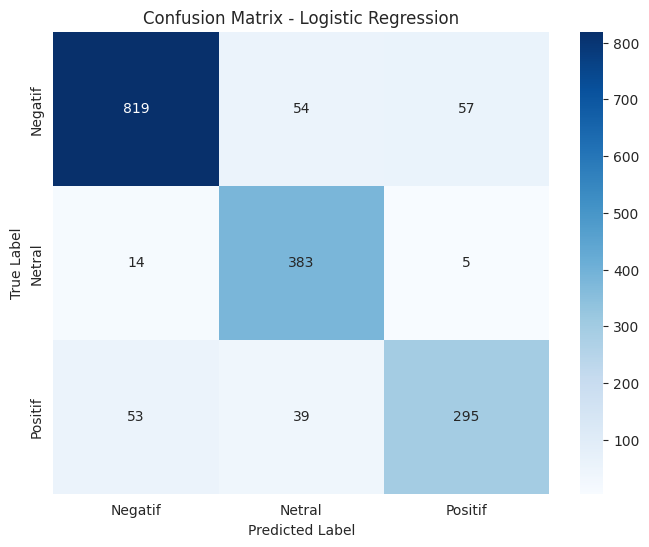


⚙️ Optimizing Random Forest...
Fitting 3 folds for each of 10 candidates, totalling 30 fits

✅ Random Forest optimization complete!
Best Parameters: {'randomforestclassifier__max_depth': None, 'randomforestclassifier__min_samples_split': 11, 'randomforestclassifier__n_estimators': 287}
Accuracy: 0.8389
F1-Score: 0.8378
Classification Report:
              precision    recall  f1-score   support

     Negatif       0.90      0.85      0.87       930
      Netral       0.77      0.96      0.85       402
     Positif       0.78      0.70      0.74       387

    accuracy                           0.84      1719
   macro avg       0.82      0.83      0.82      1719
weighted avg       0.84      0.84      0.84      1719



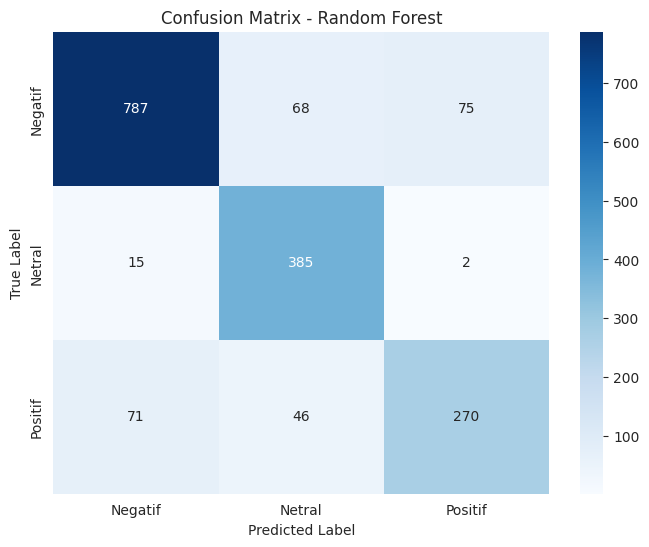


⚙️ Optimizing Naive Bayes...
Fitting 3 folds for each of 5 candidates, totalling 15 fits


/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 5 is smaller than n_iter=15. Running 5 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(



✅ Naive Bayes optimization complete!
Best Parameters: {'multinomialnb__alpha': 2.0}
Accuracy: 0.7807
F1-Score: 0.7870
Classification Report:
              precision    recall  f1-score   support

     Negatif       0.89      0.79      0.83       930
      Netral       0.82      0.78      0.80       402
     Positif       0.58      0.76      0.66       387

    accuracy                           0.78      1719
   macro avg       0.76      0.78      0.76      1719
weighted avg       0.80      0.78      0.79      1719



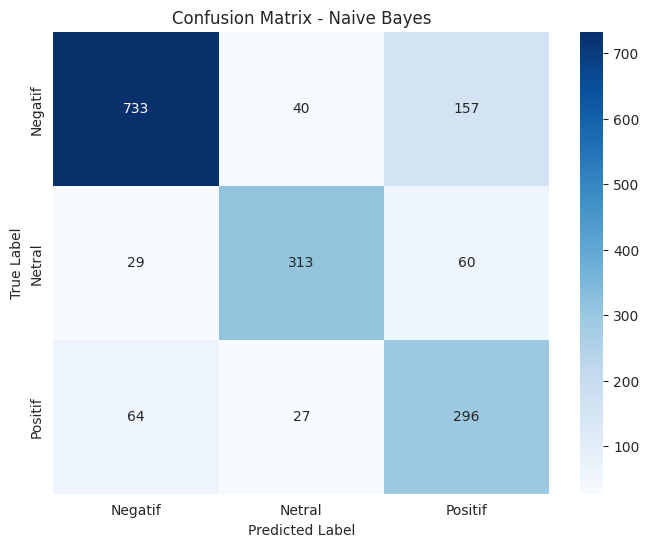

In [65]:
# Block 7: Training dan Evaluasi Semua Model
results = {}
for name in classifiers:
    results[name] = train_and_evaluate_model(name, classifiers[name], param_grids[name])

### Visualisasi


🏆 FINAL MODEL COMPARISON

📊 PERFORMANCE SUMMARY:


,Model,Accuracy,F1-Score,Precision,Recall
0,Logistic Regression,0.8709,0.8705,0.8743,0.8709
1,Random Forest,0.8389,0.8378,0.8433,0.8389
2,Naive Bayes,0.7807,0.7870,0.8026,0.7807


<Figure size 1400x800 with 0 Axes>

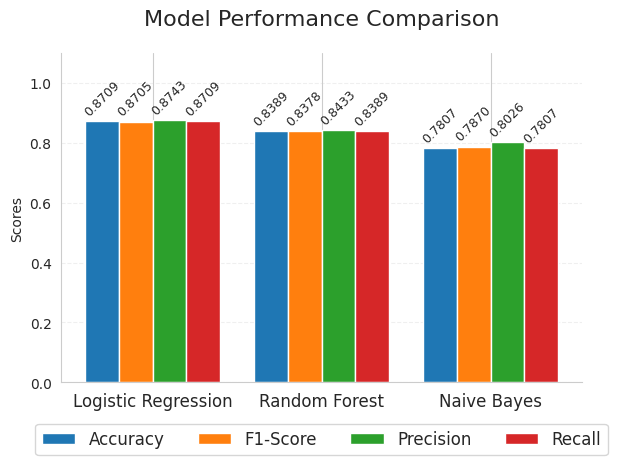


🎯 BEST MODEL: Logistic Regression (F1-Score: 0.8705)

🔍 TOP FEATURES FOR LOGISTIC REGRESSION

📌 Class: Negatif
Feature              Coefficient
--------------------------------
kabur                    22.2840
kayak                    10.2622
ikut                      8.6358
cari                      8.3446
salah                     8.3329
pilih                     7.9550
tau                       7.6056
gua                       7.5273
anak                      7.0339
bahasa                    6.5193
allah                    -4.0289
kaburajadulu             -3.6712
tuhan                    -3.5341
guru                     -3.3769
aja                      -2.9128
pasang                   -2.8085
tarik                    -2.7719
dukung                   -2.7369
manfaat                  -2.5830
kait                     -2.5336

📌 Class: Netral
Feature              Coefficient
--------------------------------
kabur                   -15.5310
ya                      -15.2905
banget       

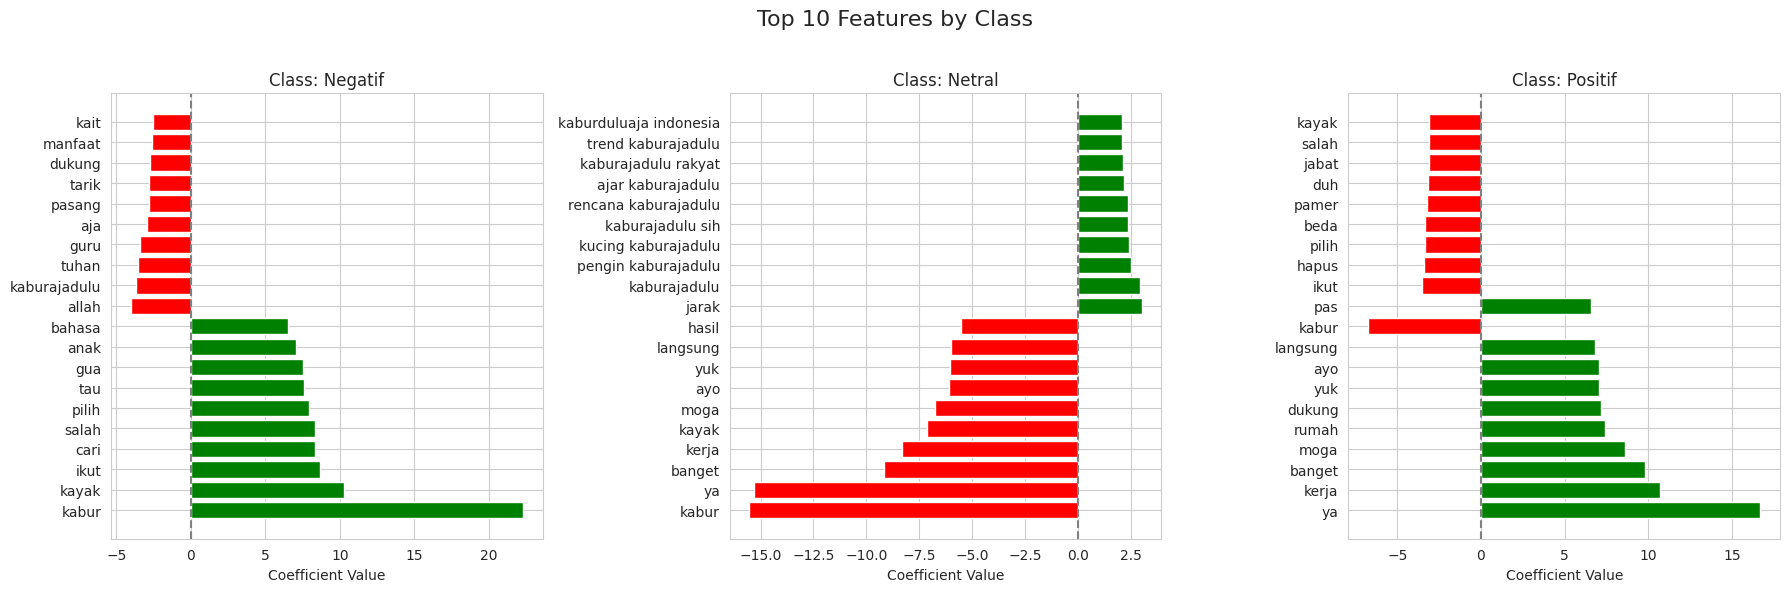


📈 CONFUSION MATRIX FOR BEST MODEL (Logistic Regression)


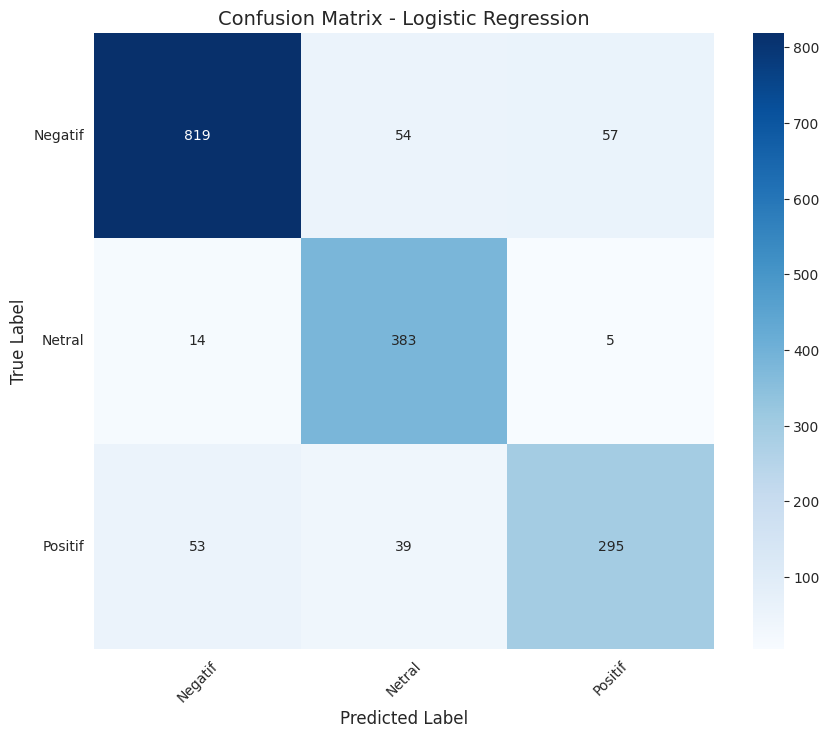


📝 CLASSIFICATION REPORT:


,precision,recall,f1-score,support
Negatif,0.924400,0.880600,0.902000,930.000000
Netral,0.804600,0.952700,0.872400,402.000000
Positif,0.826300,0.762300,0.793000,387.000000
accuracy,0.870900,0.870900,0.870900,0.870900
macro avg,0.851800,0.865200,0.855800,1719.000000
weighted avg,0.874300,0.870900,0.870500,1719.000000


In [66]:
# Block 8: Perbandingan Model dan Analisis Model Terbaik
print("\n" + "="*50)
print("🏆 FINAL MODEL COMPARISON")
print("="*50)

successful_models = {k: v for k, v in results.items() if v is not None}

if successful_models:
    # Create comparison DataFrame
    comparison = pd.DataFrame({
        'Model': list(successful_models.keys()),
        'Accuracy': [res['accuracy'] for res in successful_models.values()],
        'F1-Score': [res['f1'] for res in successful_models.values()],
        'Precision': [res['precision'] for res in successful_models.values()],
        'Recall': [res['recall'] for res in successful_models.values()]
    }).sort_values('F1-Score', ascending=False)

    # Print styled comparison table
    print("\n📊 PERFORMANCE SUMMARY:")
    display(comparison.style
            .background_gradient(cmap='Blues', subset=['Accuracy', 'F1-Score', 'Precision', 'Recall'])
            .format('{:.4f}', subset=['Accuracy', 'F1-Score', 'Precision', 'Recall'])
            .set_caption('Model Performance Comparison'))

    # Visualize model comparison with enhanced plot
    plt.figure(figsize=(14, 8))
    metrics = ['Accuracy', 'F1-Score', 'Precision', 'Recall']
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

    x = np.arange(len(comparison['Model']))
    width = 0.2

    fig, ax = plt.subplots()
    for i, metric in enumerate(metrics):
        ax.bar(x + i*width, comparison[metric], width, label=metric, color=colors[i])

        # Add values on top of bars
        for j, val in enumerate(comparison[metric]):
            ax.text(x[j] + i*width, val + 0.01, f'{val:.4f}',
                    ha='center', va='bottom', fontsize=9, rotation=45)

    # Add some text for labels, title and custom x-axis tick labels
    ax.set_ylabel('Scores')
    ax.set_title('Model Performance Comparison', fontsize=16, pad=20)
    ax.set_xticks(x + width*1.5)
    ax.set_xticklabels(comparison['Model'], fontsize=12)
    ax.set_ylim(0, 1.1)
    ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.1), ncol=4, fontsize=12)

    # Add grid for better readability
    ax.grid(True, linestyle='--', alpha=0.3, axis='y')

    # Remove top and right spines
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    plt.tight_layout()
    plt.show()

    # Select best model
    best_model_name = comparison.iloc[0]['Model']
    best_model = results[best_model_name]['model']
    print(f"\n🎯 BEST MODEL: {best_model_name} (F1-Score: {comparison.iloc[0]['F1-Score']:.4f})")

    # Feature importance analysis for Logistic Regression
    if "Logistic" in best_model_name:
        print("\n" + "="*50)
        print("🔍 TOP FEATURES FOR LOGISTIC REGRESSION")
        print("="*50)

        lr_model = best_model.named_steps['logisticregression']
        feature_names = vectorizer.get_feature_names_out()

        # Create subplots for each class
        fig, axes = plt.subplots(nrows=1, ncols=len(le.classes_), figsize=(18, 6))
        fig.suptitle('Top 10 Features by Class', fontsize=16)

        for i, class_label in enumerate(le.classes_):
            print(f"\n📌 Class: {class_label}")

            coefs = lr_model.coef_[i]
            # Get top 10 positive and top 10 negative features
            top_pos_indices = np.argsort(coefs)[-10:]
            top_neg_indices = np.argsort(coefs)[:10]

            # Combine and sort by absolute value
            top_indices = np.concatenate([top_neg_indices, top_pos_indices])
            top_features = [(feature_names[idx], coefs[idx]) for idx in top_indices]
            top_features = sorted(top_features, key=lambda x: abs(x[1]), reverse=True)[:20]

            # Print table
            print(f"{'Feature':<20}{'Coefficient':>12}")
            print("-"*32)
            for feature, coef in top_features:
                print(f"{feature:<20}{coef:>12.4f}")

            # Plot for this class
            if len(le.classes_) > 1:
                ax = axes[i]
            else:
                ax = axes

            feature_names_plot = [f[0] for f in top_features]
            coef_values = [f[1] for f in top_features]
            colors = ['red' if val < 0 else 'green' for val in coef_values]

            ax.barh(feature_names_plot, coef_values, color=colors)
            ax.set_title(f'Class: {class_label}')
            ax.axvline(0, color='gray', linestyle='--')
            ax.set_xlabel('Coefficient Value')

        plt.tight_layout(rect=[0, 0, 1, 0.96])
        plt.show()

    # Confusion matrix for best model
    print("\n" + "="*50)
    print(f"📈 CONFUSION MATRIX FOR BEST MODEL ({best_model_name})")
    print("="*50)

    y_pred_best = best_model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred_best)

    plt.figure(figsize=(10, 8))
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=le.classes_,
        yticklabels=le.classes_
    )
    plt.title(f'Confusion Matrix - {best_model_name}', fontsize=14)
    plt.ylabel('True Label', fontsize=12)
    plt.xlabel('Predicted Label', fontsize=12)
    plt.xticks(rotation=45)
    plt.yticks(rotation=0)
    plt.show()

    # Classification report as table
    print("\n📝 CLASSIFICATION REPORT:")
    report = classification_report(y_test, y_pred_best, target_names=le.classes_, output_dict=True)
    report_df = pd.DataFrame(report).transpose().round(4)
    display(report_df.style.background_gradient(cmap='Blues', subset=['precision', 'recall', 'f1-score']))

else:
    print("⚠️ No models successfully trained!")

# Save Model

In [67]:
# Block 9a: Mount Google Drive
from google.colab import drive
import os

print("📤 Mounting Google Drive...")
drive.mount('/content/drive', force_remount=True)

# Buat direktori utama untuk menyimpan model
base_dir = "/content/drive/MyDrive/sentiment_analysis_models"
os.makedirs(base_dir, exist_ok=True)
print(f"📂 Base directory created: {base_dir}")

📤 Mounting Google Drive...
Mounted at /content/drive
📂 Base directory created: /content/drive/MyDrive/sentiment_analysis_models


In [68]:
# Block 9b: Prepare Model Directory
import datetime

# Generate timestamped folder name
timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
model_dir = os.path.join(base_dir, f"model_{timestamp}")
os.makedirs(model_dir, exist_ok=True)

print("\n" + "="*50)
print(f"📁 PREPARING MODEL DIRECTORY: {model_dir}")
print("="*50)
print(f"✅ Model directory created")


📁 PREPARING MODEL DIRECTORY: /content/drive/MyDrive/sentiment_analysis_models/model_20250624_040948
✅ Model directory created


In [69]:
# Block 9c: Save Core Components (Fixed)
import joblib
import json
import numpy as np
import pandas as pd

# Fungsi untuk konversi tipe data non-serializable
def convert_to_serializable(obj):
    if isinstance(obj, (np.integer, np.int64)):
        return int(obj)
    elif isinstance(obj, (np.floating, np.float64)):
        return float(obj)
    elif isinstance(obj, np.ndarray):
        return obj.tolist()
    elif isinstance(obj, pd.Series):
        return obj.to_dict()
    elif hasattr(obj, '__dict__'):
        return obj.__dict__
    else:
        return obj

if successful_models:
    # 1. Simpan model terbaik
    model_path = os.path.join(model_dir, "best_model.pkl")
    joblib.dump(best_model, model_path)
    print(f"✅ Saved best model ({best_model_name}) to: {model_path}")

    # 2. Simpan vectorizer
    vectorizer_path = os.path.join(model_dir, "tfidf_vectorizer.pkl")
    joblib.dump(vectorizer, vectorizer_path)
    print(f"✅ Saved TF-IDF vectorizer to: {vectorizer_path}")

    # 3. Simpan label encoder
    label_encoder_path = os.path.join(model_dir, "label_encoder.pkl")
    joblib.dump(le, label_encoder_path)
    print(f"✅ Saved label encoder to: {label_encoder_path}")

    # 4. Simpan metadata dengan konversi tipe data
    metadata = {
        'model_name': best_model_name,
        'creation_date': timestamp,
        'classes': le.classes_.tolist(),
        'label_mapping': {k: convert_to_serializable(v) for k, v in label_mapping.items()},
        'performance': {
            'accuracy': convert_to_serializable(results[best_model_name]['accuracy']),
            'f1_score': convert_to_serializable(results[best_model_name]['f1']),
            'precision': convert_to_serializable(results[best_model_name]['precision']),
            'recall': convert_to_serializable(results[best_model_name]['recall'])
        },
        'dataset_info': {
            'num_samples': len(X),
            'num_features': X_transformed.shape[1],
            'class_distribution': convert_to_serializable(pd.Series(y).value_counts())
        }
    }

    metadata_path = os.path.join(model_dir, "metadata.json")
    with open(metadata_path, 'w') as f:
        json.dump(metadata, f, indent=2, default=convert_to_serializable)
    print(f"✅ Saved metadata to: {metadata_path}")
else:
    print("⚠️ No models to save!")

✅ Saved best model (Logistic Regression) to: /content/drive/MyDrive/sentiment_analysis_models/model_20250624_040948/best_model.pkl
✅ Saved TF-IDF vectorizer to: /content/drive/MyDrive/sentiment_analysis_models/model_20250624_040948/tfidf_vectorizer.pkl
✅ Saved label encoder to: /content/drive/MyDrive/sentiment_analysis_models/model_20250624_040948/label_encoder.pkl
✅ Saved metadata to: /content/drive/MyDrive/sentiment_analysis_models/model_20250624_040948/metadata.json


In [70]:
# Block 9d: Save Inference Script and Visualizations
import shutil
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

if successful_models:
    # 5. Simpan contoh penggunaan (inference script)
    inference_script = f"""# Sentiment Analysis Inference Script
import joblib
import json
import numpy as np

class SentimentAnalyzer:
    def __init__(self, model_dir):
        \"\"\"Load model components from directory\"\"\"
        self.model = joblib.load(f'{{model_dir}}/best_model.pkl')
        self.vectorizer = joblib.load(f'{{model_dir}}/tfidf_vectorizer.pkl')
        self.le = joblib.load(f'{{model_dir}}/label_encoder.pkl')

        with open(f'{{model_dir}}/metadata.json', 'r') as f:
            self.metadata = json.load(f)

    def predict(self, texts, return_proba=False):
        \"\"\"Predict sentiment for a list of texts\"\"\"
        # Vectorize texts
        X = self.vectorizer.transform(texts)

        # Predict
        predictions = self.model.predict(X)
        predicted_labels = self.le.inverse_transform(predictions)

        results = {{
            'predictions': predicted_labels.tolist()
        }}

        if return_proba and hasattr(self.model, 'predict_proba'):
            probabilities = self.model.predict_proba(X)
            results['probabilities'] = probabilities.tolist()

        return results

if __name__ == "__main__":
    # Example usage
    model_path = "{model_dir}"  # Update with your actual path
    analyzer = SentimentAnalyzer(model_path)

    test_texts = [
        "Produk ini sangat bagus dan memuaskan",
        "Saya kecewa dengan pelayanannya",
        "Barang biasa saja, tidak istimewa"
    ]

    results = analyzer.predict(test_texts, return_proba=True)

    print("\\n🔮 Prediction Results:")
    for i, text in enumerate(test_texts):
        print(f"\\nText: {{text}}")
        print(f"Predicted: {{results['predictions'][i]}}")

        if 'probabilities' in results:
            print("Probabilities:")
            for cls, prob in zip(analyzer.metadata['classes'], results['probabilities'][i]):
                print(f"  {{cls}}: {{prob:.4f}}")

    print("\\n" + "="*50)
    print("Model Info:")
    print(f"Name: {{analyzer.metadata['model_name']}}")
    print(f"Created: {{analyzer.metadata['creation_date']}}")
    print(f"Classes: {{', '.join(analyzer.metadata['classes'])}}")
"""

    script_path = os.path.join(model_dir, "sentiment_analyzer.py")
    with open(script_path, 'w') as f:
        f.write(inference_script)
    print(f"✅ Saved inference script to: {script_path}")

    # 6. Simpan visualisasi
    # Confusion matrix
    plt.figure(figsize=(10, 8))
    sns.heatmap(
        confusion_matrix(y_test, y_pred_best),
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=le.classes_,
        yticklabels=le.classes_
    )
    plt.title(f'Confusion Matrix - {best_model_name}')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    cm_path = os.path.join(model_dir, "confusion_matrix.png")
    plt.savefig(cm_path, bbox_inches='tight')
    plt.close()
    print(f"✅ Saved confusion matrix to: {cm_path}")

    # Model comparison chart
    plt.figure(figsize=(14, 8))
    metrics = ['Accuracy', 'F1-Score', 'Precision', 'Recall']
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

    x = np.arange(len(comparison['Model']))
    width = 0.2

    fig, ax = plt.subplots()
    for i, metric in enumerate(metrics):
        ax.bar(x + i*width, comparison[metric], width, label=metric, color=colors[i])

        for j, val in enumerate(comparison[metric]):
            ax.text(x[j] + i*width, val + 0.01, f'{{val:.4f}}',
                    ha='center', va='bottom', fontsize=9, rotation=45)

    ax.set_ylabel('Scores')
    ax.set_title('Model Performance Comparison', fontsize=16)
    ax.set_xticks(x + width*1.5)
    ax.set_xticklabels(comparison['Model'], fontsize=12)
    ax.set_ylim(0, 1.1)
    ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.1), ncol=4, fontsize=12)
    ax.grid(True, linestyle='--', alpha=0.3, axis='y')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    comparison_path = os.path.join(model_dir, "model_comparison.png")
    plt.savefig(comparison_path, bbox_inches='tight')
    plt.close()
    print(f"✅ Saved model comparison chart to: {comparison_path}")

    print("\n🎉 All model components saved to Google Drive!")
    print(f"📁 Path: {model_dir}")

✅ Saved inference script to: /content/drive/MyDrive/sentiment_analysis_models/model_20250624_040948/sentiment_analyzer.py
✅ Saved confusion matrix to: /content/drive/MyDrive/sentiment_analysis_models/model_20250624_040948/confusion_matrix.png
✅ Saved model comparison chart to: /content/drive/MyDrive/sentiment_analysis_models/model_20250624_040948/model_comparison.png

🎉 All model components saved to Google Drive!
📁 Path: /content/drive/MyDrive/sentiment_analysis_models/model_20250624_040948


<Figure size 1400x800 with 0 Axes>

In [71]:
# Block 9e: Verify Saved Files
if successful_models:
    print("\n" + "="*50)
    print("🔍 VERIFYING SAVED FILES")
    print("="*50)

    saved_files = os.listdir(model_dir)
    print("Saved files:")
    for file in saved_files:
        print(f"- {file}")

    print("\n💡 You can access these files in your Google Drive under:")
    print(f"Drive > MyDrive > sentiment_analysis_models > model_{timestamp}")

    # Tampilkan contoh penggunaan
    print("\n💻 Example usage:")
    print(f"from sentiment_analyzer import SentimentAnalyzer")
    print(f"analyzer = SentimentAnalyzer('{model_dir}')")
    print(f"results = analyzer.predict(['contoh teks'], return_proba=True)")

    # Tampilkan struktur folder
    print("\n📁 Folder structure:")
    print(f"model_{timestamp}/")
    print("├── best_model.pkl")
    print("├── tfidf_vectorizer.pkl")
    print("├── label_encoder.pkl")
    print("├── metadata.json")
    print("├── sentiment_analyzer.py")
    print("├── confusion_matrix.png")
    print("└── model_comparison.png")


🔍 VERIFYING SAVED FILES
Saved files:
- best_model.pkl
- tfidf_vectorizer.pkl
- label_encoder.pkl
- metadata.json
- sentiment_analyzer.py
- confusion_matrix.png
- model_comparison.png

💡 You can access these files in your Google Drive under:
Drive > MyDrive > sentiment_analysis_models > model_20250624_040948

💻 Example usage:
from sentiment_analyzer import SentimentAnalyzer
analyzer = SentimentAnalyzer('/content/drive/MyDrive/sentiment_analysis_models/model_20250624_040948')
results = analyzer.predict(['contoh teks'], return_proba=True)

📁 Folder structure:
model_20250624_040948/
├── best_model.pkl
├── tfidf_vectorizer.pkl
├── label_encoder.pkl
├── metadata.json
├── sentiment_analyzer.py
├── confusion_matrix.png
└── model_comparison.png


# Inference

In [72]:
# Block 10a: Mount Google Drive and Find Latest Model
from google.colab import drive
import os
import joblib
import json

print("📤 Mounting Google Drive...")
drive.mount('/content/drive')

# Set base directory
base_dir = "/content/drive/MyDrive/sentiment_analysis_models"
os.makedirs(base_dir, exist_ok=True)
print(f"📂 Base directory: {base_dir}")

# Find latest model
print("\n🔍 Searching for latest model...")
model_dirs = sorted(
    [d for d in os.listdir(base_dir) if d.startswith("model_") and os.path.isdir(os.path.join(base_dir, d))],
    reverse=True
)

if not model_dirs:
    print("❌ No models found in Google Drive!")
    model_dir = None
else:
    model_dir = os.path.join(base_dir, model_dirs[0])
    print(f"✅ Found latest model: {model_dir}")

📤 Mounting Google Drive...
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
📂 Base directory: /content/drive/MyDrive/sentiment_analysis_models

🔍 Searching for latest model...
✅ Found latest model: /content/drive/MyDrive/sentiment_analysis_models/model_20250624_040948


In [73]:
# Block 10b: Load Model Components
if model_dir and os.path.exists(model_dir):
    print("\n" + "="*50)
    print("🔄 LOADING MODEL COMPONENTS")
    print("="*50)

    try:
        # Load model
        model = joblib.load(os.path.join(model_dir, "best_model.pkl"))
        print("✅ Loaded best model")

        # Load vectorizer
        vectorizer = joblib.load(os.path.join(model_dir, "tfidf_vectorizer.pkl"))
        print("✅ Loaded TF-IDF vectorizer")

        # Load label encoder
        le = joblib.load(os.path.join(model_dir, "label_encoder.pkl"))
        print("✅ Loaded label encoder")

        # Load metadata
        with open(os.path.join(model_dir, "metadata.json"), 'r') as f:
            metadata = json.load(f)
        print("✅ Loaded metadata")

        print(f"\nModel Name: {metadata['model_name']}")
        print(f"Created: {metadata['creation_date']}")
        print(f"Classes: {', '.join(metadata['classes'])}")

    except Exception as e:
        print(f"❌ Error loading model components: {str(e)}")
        model = None
else:
    print("❌ Model directory not available")
    model = None


🔄 LOADING MODEL COMPONENTS
✅ Loaded best model
✅ Loaded TF-IDF vectorizer
✅ Loaded label encoder
✅ Loaded metadata

Model Name: Logistic Regression
Created: 20250624_040948
Classes: Negatif, Netral, Positif


In [74]:
# Block 10c: Prepare Test Texts
print("\n" + "="*50)
print("📝 PREPARING TEST TEXTS WITH #kaburajadulu THEME")
print("="*50)

test_texts = [
    "Baru tau #kaburajadulu viral di twitter, lucu banget 🤣",
    "Kok bisa ya #kaburajadulu jadi trending? Aku malah belum paham artinya 😅",
    "Kasian yang kena tipu sama akun palsu #kaburajadulu, jangan mudah percaya sama berita hoax!",
    "Wah seru banget meme #kaburajadulu ini, bikin ngakak seharian 😂",
    "Awas banyak akun palsu nyebarin hoax pake tagar #kaburajadulu, jangan sampai ketipu!",
    "Gak ngerti maksud #kaburajadulu apa, tapi kok rame banget ya di timeline?",
    "Baru bangun tidur langsung diserbu #kaburajadulu, ada apa ini? 😴",
    "Jangan lupa cek fakta sebelum share info soal #kaburajadulu, banyak hoaxnya!",
    "Lucu-lucu banget meme #kaburajadulu ini, bikin mood naik seharian 😄",
    "Serem juga ya ada yang pake #kaburajadulu buat nipu orang, hati-hati guys!"
]

print("Test Texts:")
for i, text in enumerate(test_texts, 1):
    print(f"{i}. {text}")


📝 PREPARING TEST TEXTS WITH #kaburajadulu THEME
Test Texts:
1. Baru tau #kaburajadulu viral di twitter, lucu banget 🤣
2. Kok bisa ya #kaburajadulu jadi trending? Aku malah belum paham artinya 😅
3. Kasian yang kena tipu sama akun palsu #kaburajadulu, jangan mudah percaya sama berita hoax!
4. Wah seru banget meme #kaburajadulu ini, bikin ngakak seharian 😂
5. Awas banyak akun palsu nyebarin hoax pake tagar #kaburajadulu, jangan sampai ketipu!
6. Gak ngerti maksud #kaburajadulu apa, tapi kok rame banget ya di timeline?
7. Baru bangun tidur langsung diserbu #kaburajadulu, ada apa ini? 😴
8. Jangan lupa cek fakta sebelum share info soal #kaburajadulu, banyak hoaxnya!
9. Lucu-lucu banget meme #kaburajadulu ini, bikin mood naik seharian 😄
10. Serem juga ya ada yang pake #kaburajadulu buat nipu orang, hati-hati guys!


In [75]:
# Block 10d: Define Prediction Function
import numpy as np
import pandas as pd

def predict_sentiment(texts, return_proba=False):
    """
    Predict sentiment for a list of texts
    """
    # Ensure texts are strings
    texts = [str(text) for text in texts]

    # Vectorize texts
    X = vectorizer.transform(texts)

    # Predict
    predictions = model.predict(X)
    predicted_labels = le.inverse_transform(predictions)

    results = {
        'texts': texts,
        'predictions': predicted_labels
    }

    # Add probabilities if available
    if return_proba and hasattr(model, 'predict_proba'):
        probabilities = model.predict_proba(X)
        results['probabilities'] = probabilities

    return results

print("\n✅ Prediction function defined")


✅ Prediction function defined



🔮 RUNNING PREDICTIONS

📊 PREDICTION RESULTS:


,Text,Prediction,Prob_Negatif,Prob_Netral,Prob_Positif,Sentiment
0,"Baru tau #kaburajadulu viral di twitter, lucu banget 🤣",Negatif,0.839330,0.001986,0.158684,😠
1,Kok bisa ya #kaburajadulu jadi trending? Aku malah belum paham artinya 😅,Positif,0.177475,0.099215,0.723311,😊
2,"Kasian yang kena tipu sama akun palsu #kaburajadulu, jangan mudah percaya sama berita hoax!",Negatif,0.859312,0.029937,0.110750,😠
3,"Wah seru banget meme #kaburajadulu ini, bikin ngakak seharian 😂",Positif,0.029666,0.063550,0.906783,😊
4,"Awas banyak akun palsu nyebarin hoax pake tagar #kaburajadulu, jangan sampai ketipu!",Negatif,0.776913,0.172136,0.050951,😠
5,"Gak ngerti maksud #kaburajadulu apa, tapi kok rame banget ya di timeline?",Positif,0.023840,0.000194,0.975966,😊
6,"Baru bangun tidur langsung diserbu #kaburajadulu, ada apa ini? 😴",Positif,0.411575,0.017610,0.570815,😊
7,"Jangan lupa cek fakta sebelum share info soal #kaburajadulu, banyak hoaxnya!",Negatif,0.858858,0.115923,0.025220,😠
8,"Lucu-lucu banget meme #kaburajadulu ini, bikin mood naik seharian 😄",Positif,0.012268,0.013792,0.973939,😊
9,"Serem juga ya ada yang pake #kaburajadulu buat nipu orang, hati-hati guys!",Positif,0.057025,0.002239,0.940736,😊



📈 SENTIMENT DISTRIBUTION:


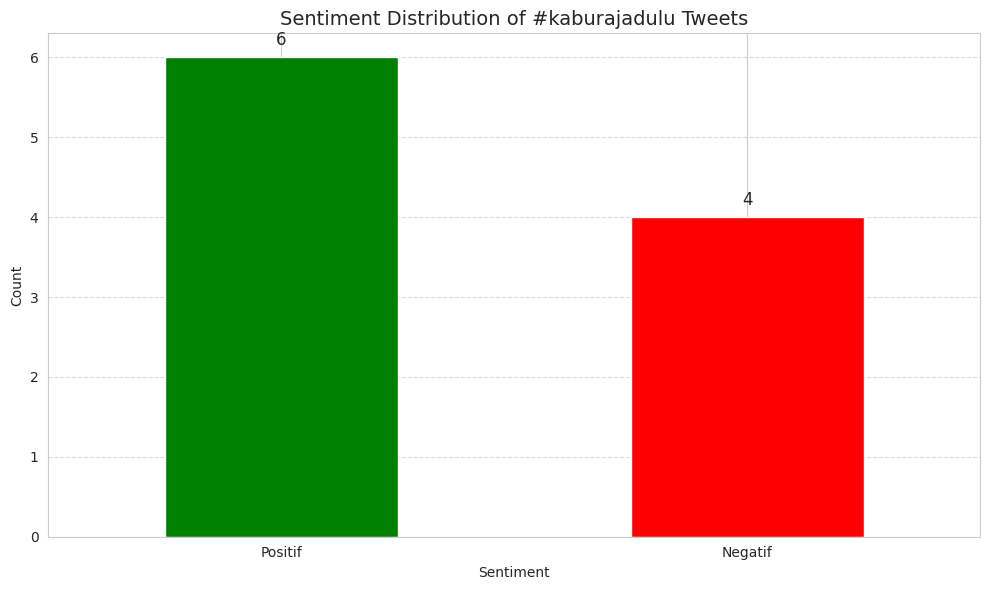


📌 SAMPLE TWEETS BY SENTIMENT:

🔹 Positif Tweets:
- Kok bisa ya #kaburajadulu jadi trending? Aku malah belum paham artinya 😅
- Wah seru banget meme #kaburajadulu ini, bikin ngakak seharian 😂

🔹 Netral Tweets:
No Netral tweets found in the test samples

🔹 Negatif Tweets:
- Kasian yang kena tipu sama akun palsu #kaburajadulu, jangan mudah percaya sama berita hoax!
- Awas banyak akun palsu nyebarin hoax pake tagar #kaburajadulu, jangan sampai ketipu!


In [76]:
# Block 10e: Run Predictions and Show Results
if model:
    print("\n" + "="*50)
    print("🔮 RUNNING PREDICTIONS")
    print("="*50)

    # Get predictions
    results = predict_sentiment(test_texts, return_proba=True)

    # Create DataFrame for results
    results_df = pd.DataFrame({
        'Text': results['texts'],
        'Prediction': results['predictions']
    })

    # Add probabilities if available
    if 'probabilities' in results:
        prob_df = pd.DataFrame(
            results['probabilities'],
            columns=[f"Prob_{cls}" for cls in metadata['classes']]
        )
        results_df = pd.concat([results_df, prob_df], axis=1)

    # Add sentiment emoji
    sentiment_emoji = {
        'Positif': '😊',
        'Netral': '😐',
        'Negatif': '😠'
    }
    results_df['Sentiment'] = results_df['Prediction'].map(sentiment_emoji)

    # Display results
    print("\n📊 PREDICTION RESULTS:")
    display(results_df.style
           .bar(subset=[f"Prob_{cls}" for cls in metadata['classes']], color='#5fba7d')
           .apply(lambda x: [f"color: {'green' if x == 'Positif' else 'red' if x == 'Negatif' else 'gray'}" for x in x],
                  subset=['Prediction'])
           .set_caption('Sentiment Analysis Results for #kaburajadulu'))

    # Sentiment distribution visualization
    print("\n📈 SENTIMENT DISTRIBUTION:")
    plt.figure(figsize=(10, 6))
    sentiment_counts = results_df['Prediction'].value_counts()

    # Create color mapping
    color_map = {'Positif': 'green', 'Netral': 'gray', 'Negatif': 'red'}
    colors = [color_map.get(s, 'blue') for s in sentiment_counts.index]

    # Create plot
    ax = sentiment_counts.plot(kind='bar', color=colors)
    plt.title('Sentiment Distribution of #kaburajadulu Tweets', fontsize=14)
    plt.xlabel('Sentiment')
    plt.ylabel('Count')
    plt.xticks(rotation=0)

    # Add counts on top of bars
    for i, count in enumerate(sentiment_counts):
        ax.text(i, count + 0.1, str(count), ha='center', va='bottom', fontsize=12)

    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

    # Show sample tweets by sentiment - PERBAIKAN DI SINI
    print("\n📌 SAMPLE TWEETS BY SENTIMENT:")
    for sentiment in ['Positif', 'Netral', 'Negatif']:
        print(f"\n🔹 {sentiment} Tweets:")

        # Filter tweets by sentiment
        sentiment_tweets = results_df[results_df['Prediction'] == sentiment]

        # Periksa apakah ada tweet untuk sentimen ini
        if not sentiment_tweets.empty:
            # Ambil maksimal 2 sampel
            sample_count = min(2, len(sentiment_tweets))
            sample_tweets = sentiment_tweets.sample(sample_count)['Text'].tolist()

            for tweet in sample_tweets:
                print(f"- {tweet}")
        else:
            print(f"No {sentiment} tweets found in the test samples")
else:
    print("❌ Cannot run predictions without model")